**PROPERTY MARKET ANALYSIS**

ADVANCED DATA SCIENCE & ANALYTICS GROUP 17

**IMPORTING REQUIRED LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**IMPORTING DATASET FROM KAGGLE**

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("new-york-city/nyc-property-sales")

print("Path to dataset files:", path)

100%|██████████| 1.81M/1.81M [00:00<00:00, 61.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/new-york-city/nyc-property-sales/versions/1


**READING THE DATASET**

In [3]:
import os
import pandas as pd

# List files in the downloaded dataset path
files = os.listdir(path)
print(f"Files in the dataset directory: {files}")

# Assuming the main data file is a CSV, let's find and load it
csv_file = [f for f in files if f.endswith('.csv')]

if csv_file:
    # Assuming the first CSV file found is the one to load
    data_file_path = os.path.join(path, csv_file[0])
    df = pd.read_csv(data_file_path)
    print(f"Successfully loaded {len(df)} rows from {csv_file[0]}")
    print(df.head())
else:
    print("No CSV files found in the dataset directory.")

Files in the dataset directory: ['nyc-rolling-sales.csv']
Successfully loaded 84548 rows from nyc-rolling-sales.csv
   Unnamed: 0  BOROUGH   NEIGHBORHOOD  \
0           4        1  ALPHABET CITY   
1           5        1  ALPHABET CITY   
2           6        1  ALPHABET CITY   
3           7        1  ALPHABET CITY   
4           8        1  ALPHABET CITY   

                       BUILDING CLASS CATEGORY TAX CLASS AT PRESENT  BLOCK  \
0  07 RENTALS - WALKUP APARTMENTS                                2A    392   
1  07 RENTALS - WALKUP APARTMENTS                                 2    399   
2  07 RENTALS - WALKUP APARTMENTS                                 2    399   
3  07 RENTALS - WALKUP APARTMENTS                                2B    402   
4  07 RENTALS - WALKUP APARTMENTS                                2A    404   

   LOT EASE-MENT BUILDING CLASS AT PRESENT                 ADDRESS  ...  \
0    6                                  C2            153 AVENUE B  ...   
1   26            

In [4]:
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset has 84548 rows and 22 columns.


In [5]:
df['SALE DATE'] = pd.to_datetime(df['SALE DATE'], errors='coerce')
min_year = df['SALE DATE'].min().year
max_year = df['SALE DATE'].max().year
print(f"The data covers the period from {min_year} to {max_year}.")

The data covers the period from 2016 to 2017.


**DATA CLEANING**

In [6]:
print("Original DataFrame shape:", df.shape)

# Convert 'SALE PRICE' to numeric, coerce errors to NaN
df['SALE PRICE'] = pd.to_numeric(df['SALE PRICE'], errors='coerce')

# Filter out sales where sale_price is 0 or less than 10000
df = df[df['SALE PRICE'] >= 10000].copy()
print("Shape after filtering sale price (>= 10000):", df.shape)

# Convert 'GROSS SQUARE FEET' to numeric, coerce errors to NaN
df['GROSS SQUARE FEET'] = pd.to_numeric(df['GROSS SQUARE FEET'], errors='coerce')

# Filter out rows where gross_square_feet is 0 or NaN
df = df[df['GROSS SQUARE FEET'] > 0].copy()
df = df.dropna(subset=['GROSS SQUARE FEET']).copy()
print("Shape after filtering gross square feet (> 0 and not NaN):", df.shape)

# Filter for residential properties: building_class_category LIKE '01%' OR '02%' OR '03%'
residential_categories = df['BUILDING CLASS CATEGORY'].astype(str).str.startswith(('01', '02', '03'))
df = df[residential_categories].copy()
print("Shape after filtering for residential properties:", df.shape)

print("Data cleaning complete. Displaying the first 5 rows of the cleaned data:")
print(df.head())

Original DataFrame shape: (84548, 22)
Shape after filtering sale price (>= 10000): (58465, 22)
Shape after filtering gross square feet (> 0 and not NaN): (28436, 22)
Shape after filtering for residential properties: (24668, 22)
Data cleaning complete. Displaying the first 5 rows of the cleaned data:
      Unnamed: 0  BOROUGH  NEIGHBORHOOD  \
206          210        1       CHELSEA   
212          216        1       CHELSEA   
214          218        1       CHELSEA   
1791        1795        1  EAST VILLAGE   
1793        1797        1  EAST VILLAGE   

                          BUILDING CLASS CATEGORY TAX CLASS AT PRESENT  BLOCK  \
206   01 ONE FAMILY DWELLINGS                                        1    771   
212   02 TWO FAMILY DWELLINGS                                        1    769   
214   03 THREE FAMILY DWELLINGS                                      1    719   
1791  02 TWO FAMILY DWELLINGS                                        1    436   
1793  02 TWO FAMILY DWELLINGS      

**CALCULATING THE NUMBER OF SALES REMAINING**

In [7]:
# Calculate number of sales remaining
num_sales_remaining = df.shape[0]
print(f"Number of sales remaining after filtering: {num_sales_remaining}")

# Convert 'SALE DATE' to datetime objects if not already done
# (Assuming this was already done in a previous cell like IUO7RNZg16_P, but re-confirming for safety)
if not pd.api.types.is_datetime64_any_dtype(df['SALE DATE']):
    df['SALE DATE'] = pd.to_datetime(df['SALE DATE'], errors='coerce')

# Get the minimum and maximum sale dates
min_date = df['SALE DATE'].min().strftime('%Y-%m-%d')
max_date = df['SALE DATE'].max().strftime('%Y-%m-%d')

print(f"Date range covered: {min_date} to {max_date}")

Number of sales remaining after filtering: 24668
Date range covered: 2016-09-01 to 2017-08-31


In [8]:
print(f"The dataset after cleaning has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset after cleaning has 24668 rows and 22 columns.


**EXPLORATORY DATA ANALYSIS**

REMAINING SALES & DATE RANGE COVERED

In [9]:
# Calculate number of sales remaining
num_sales_remaining = df.shape[0]
print(f"Number of sales remaining after filtering: {num_sales_remaining}")

# Convert 'SALE DATE' to datetime objects
df['SALE DATE'] = pd.to_datetime(df['SALE DATE'], errors='coerce')

# Get the minimum and maximum sale dates
min_date = df['SALE DATE'].min().strftime('%Y-%m-%d')
max_date = df['SALE DATE'].max().strftime('%Y-%m-%d')

print(f"Date range covered: {min_date} to {max_date}")

Number of sales remaining after filtering: 24668
Date range covered: 2016-09-01 to 2017-08-31


In [10]:
df.head(5)

,Unnamed: 0,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,...,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
206,210,1,CHELSEA,01 ONE FAMILY DWELLINGS,1,771,52,,A9,224 WEST 22ND STREET,...,1,0,1,1975,3855.0,1901,1,A9,7425000.0,2016-12-30
212,216,1,CHELSEA,02 TWO FAMILY DWELLINGS,1,769,49,,S2,218 WEST 20TH STREET,...,2,1,3,2150,4978.0,1920,1,S2,7750000.0,2017-04-17
214,218,1,CHELSEA,03 THREE FAMILY DWELLINGS,1,719,67,,C0,444 WEST 22ND STREET,...,3,0,3,2469,3725.0,1901,1,C0,8300000.0,2017-02-02
1791,1795,1,EAST VILLAGE,02 TWO FAMILY DWELLINGS,1,436,1,,S2,138 1 AVENUE,...,2,1,3,1200,3360.0,1900,1,S2,3000000.0,2017-08-31
1793,1797,1,EAST VILLAGE,02 TWO FAMILY DWELLINGS,1,458,47,,S2,4 EAST 2ND STREET,...,2,1,3,1280,5920.0,1899,1,S2,6800000.0,2017-01-23


**MATCH BOROUGH NAME TO COUNTY NAME**

In [11]:
# Mapping Borough numbers to County Names
borough_to_county = {
    1: 'New York County (Manhattan)',
    2: 'Bronx County',
    3: 'Kings County (Brooklyn)',
    4: 'Queens County',
    5: 'Richmond County (Staten Island)'
}

df['COUNTY_NAME'] = df['BOROUGH'].map(borough_to_county)

print("Added 'COUNTY_NAME' column to the DataFrame. First 5 rows:")
print(df[['BOROUGH', 'COUNTY_NAME', 'SALE PRICE']].head())

Added 'COUNTY_NAME' column to the DataFrame. First 5 rows:
      BOROUGH                  COUNTY_NAME  SALE PRICE
206         1  New York County (Manhattan)   7425000.0
212         1  New York County (Manhattan)   7750000.0
214         1  New York County (Manhattan)   8300000.0
1791        1  New York County (Manhattan)   3000000.0
1793        1  New York County (Manhattan)   6800000.0


AVERAGE SALES BY BOROUGH

In [12]:
avg_price_by_borough = df.groupby('COUNTY_NAME')['SALE PRICE'].mean().sort_values(ascending=False)

print("Average Sale Price by Borough:")
print(avg_price_by_borough)

most_expensive_borough_name = avg_price_by_borough.index[0]
most_expensive_borough_price = avg_price_by_borough.iloc[0]
least_expensive_borough_name = avg_price_by_borough.index[-1]
least_expensive_borough_price = avg_price_by_borough.iloc[-1]

print(f"\nThe most expensive borough is {most_expensive_borough_name} with an average sale price of ${most_expensive_borough_price:,.2f}.")
print(f"The least expensive borough is {least_expensive_borough_name} with an average sale price of ${least_expensive_borough_price:,.2f}.")

Average Sale Price by Borough:
COUNTY_NAME
New York County (Manhattan)        6.574102e+06
Kings County (Brooklyn)            9.943400e+05
Queens County                      6.717441e+05
Richmond County (Staten Island)    5.163823e+05
Bronx County                       4.822053e+05
Name: SALE PRICE, dtype: float64

The most expensive borough is New York County (Manhattan) with an average sale price of $6,574,101.59.
The least expensive borough is Bronx County with an average sale price of $482,205.33.


**THE DISTRIBUTION OF SALES PRICE**

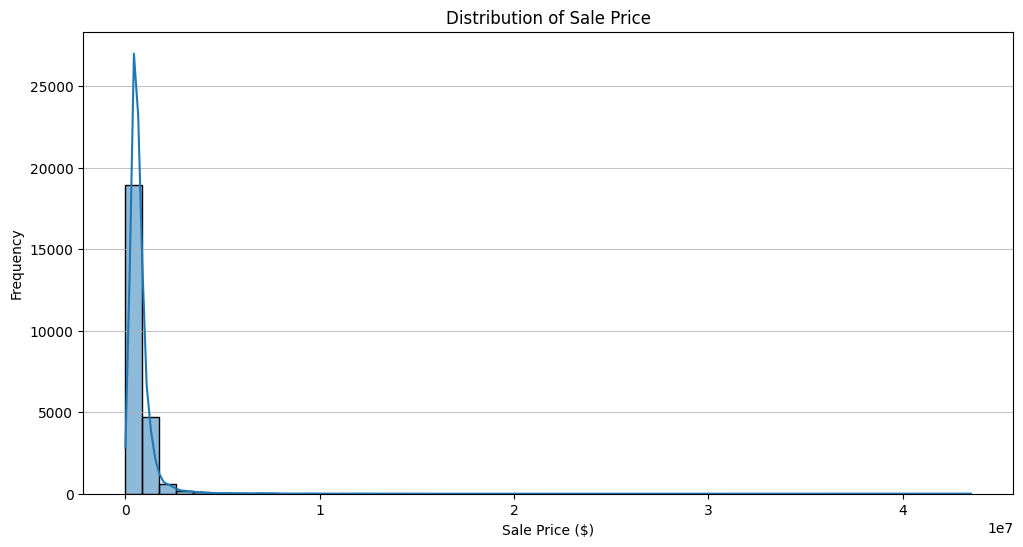


Skewness of Sale Price: 16.17
Mean Sale Price: $757,133.73
Median Sale Price: $590,000.00
The distribution of Sale Price is positively (right) skewed, indicating a longer tail on the right side due to a few very high sale prices.
A typical sale price, often better represented by the median in skewed distributions, is approximately $590,000.00.


In [13]:
plt.figure(figsize=(12, 6))
sns.histplot(df['SALE PRICE'], bins=50, kde=True)
plt.title('Distribution of Sale Price')
plt.xlabel('Sale Price ($)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

skewness = df['SALE PRICE'].skew()
mean_price = df['SALE PRICE'].mean()
median_price = df['SALE PRICE'].median()

print(f"\nSkewness of Sale Price: {skewness:.2f}")
print(f"Mean Sale Price: ${mean_price:,.2f}")
print(f"Median Sale Price: ${median_price:,.2f}")

if skewness > 0.5:
    print("The distribution of Sale Price is positively (right) skewed, indicating a longer tail on the right side due to a few very high sale prices.")
elif skewness < -0.5:
    print("The distribution of Sale Price is negatively (left) skewed, indicating a longer tail on the left side due to a few very low sale prices.")
else:
    print("The distribution of Sale Price is relatively symmetrical.")

print(f"A typical sale price, often better represented by the median in skewed distributions, is approximately ${median_price:,.2f}.")

**AVERAGE PRICE PER SQUARE FOOT**

In [14]:
# Calculate price per square foot
df['PRICE_PER_SQFT'] = df['SALE PRICE'] / df['GROSS SQUARE FEET']

# Calculate average price per square foot by borough
avg_price_sqft_by_borough = df.groupby('COUNTY_NAME')['PRICE_PER_SQFT'].mean().sort_values(ascending=False)

print("Average Price Per Square Foot by Borough:")
print(avg_price_sqft_by_borough)

# Identify the borough with the highest price per square foot
highest_price_sqft_borough = avg_price_sqft_by_borough.index[0]
highest_price_sqft_value = avg_price_sqft_by_borough.iloc[0]

print(f"\nThe borough with the highest average price per square foot is {highest_price_sqft_borough} with an average of ${highest_price_sqft_value:,.2f} per square foot.")

Average Price Per Square Foot by Borough:
COUNTY_NAME
New York County (Manhattan)        1531.357970
Kings County (Brooklyn)             469.622859
Queens County                       407.526868
Richmond County (Staten Island)     325.285320
Bronx County                        242.847743
Name: PRICE_PER_SQFT, dtype: float64

The borough with the highest average price per square foot is New York County (Manhattan) with an average of $1,531.36 per square foot.


**AVERAGE PRICE OVER TIME (YEARS)**

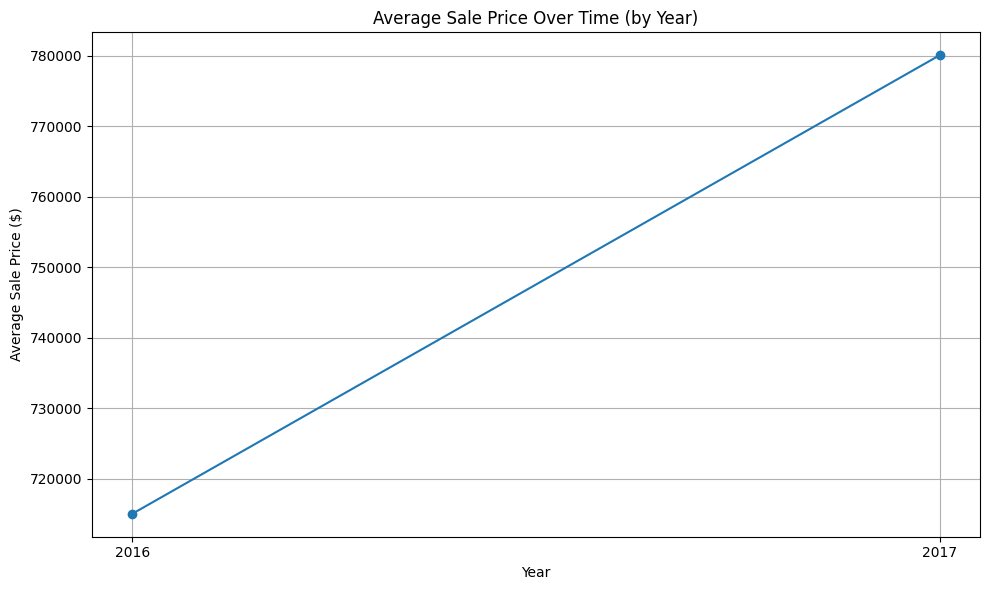

Average Sale Price by Year:
SALE_YEAR
2016    715014.006321
2017    780086.307572
Name: SALE PRICE, dtype: float64


In [15]:
df['SALE_YEAR'] = df['SALE DATE'].dt.year

avg_sale_price_by_year = df.groupby('SALE_YEAR')['SALE PRICE'].mean()

plt.figure(figsize=(10, 6))
avg_sale_price_by_year.plot(kind='line', marker='o')
plt.title('Average Sale Price Over Time (by Year)')
plt.xlabel('Year')
plt.ylabel('Average Sale Price ($)')
plt.grid(True)
plt.xticks(avg_sale_price_by_year.index)
plt.tight_layout()
plt.show()

print("Average Sale Price by Year:")
print(avg_sale_price_by_year)

In [16]:
print("Data types for each variable:")
df.info()

Data types for each variable:
<class 'pandas.core.frame.DataFrame'>
Index: 24668 entries, 206 to 84545
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Unnamed: 0                      24668 non-null  int64         
 1   BOROUGH                         24668 non-null  int64         
 2   NEIGHBORHOOD                    24668 non-null  object        
 3   BUILDING CLASS CATEGORY         24668 non-null  object        
 4   TAX CLASS AT PRESENT            24668 non-null  object        
 5   BLOCK                           24668 non-null  int64         
 6   LOT                             24668 non-null  int64         
 7   EASE-MENT                       24668 non-null  object        
 8   BUILDING CLASS AT PRESENT       24668 non-null  object        
 9   ADDRESS                         24668 non-null  object        
 10  APARTMENT NUMBER                24668 non-n

In [17]:
df['SALE DATE'] = pd.to_datetime(df['SALE DATE'], errors='coerce').dt.date
print("Updated 'SALE DATE' column to date format.")
print(df['SALE DATE'].head())
print(df['SALE DATE'].dtype)

Updated 'SALE DATE' column to date format.
206     2016-12-30
212     2017-04-17
214     2017-02-02
1791    2017-08-31
1793    2017-01-23
Name: SALE DATE, dtype: object
object


**

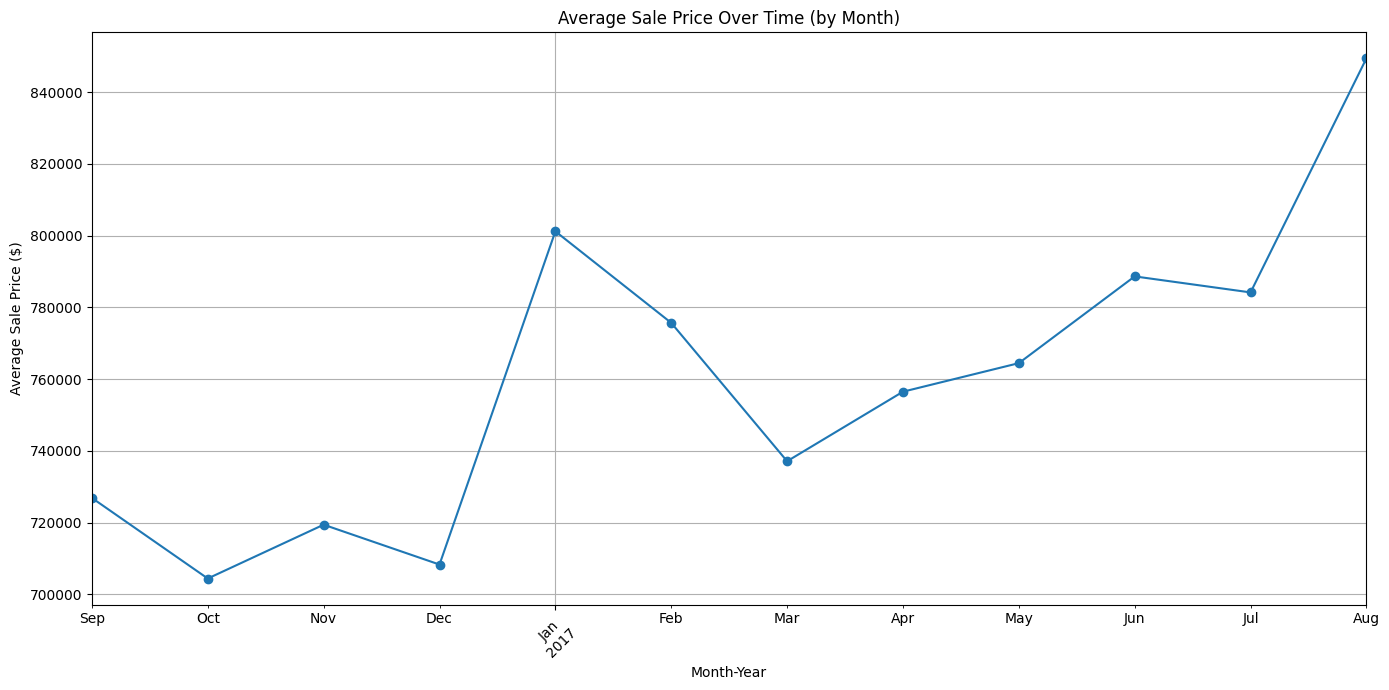

Average Sale Price by Month:
SALE_MONTH_YEAR
2016-09    726901.828037
2016-10    704447.356965
2016-11    719449.177905
2016-12    708340.728571
2017-01    801200.355992
2017-02    775692.695513
2017-03    737134.048307
2017-04    756509.263933
2017-05    764467.351120
2017-06    788642.995752
2017-07    784178.868937
2017-08    849408.915053
Freq: M, Name: SALE PRICE, dtype: float64


In [18]:
# Ensure 'SALE DATE' is in datetime format before extracting month and year
df['SALE DATE'] = pd.to_datetime(df['SALE DATE'])

# Extract month and year to create a monthly period
df['SALE_MONTH_YEAR'] = df['SALE DATE'].dt.to_period('M')

# Calculate the average sale price by month
avg_sale_price_by_month = df.groupby('SALE_MONTH_YEAR')['SALE PRICE'].mean()

# Plotting the average sale price over time by month
plt.figure(figsize=(14, 7))
avg_sale_price_by_month.plot(kind='line', marker='o')
plt.title('Average Sale Price Over Time (by Month)')
plt.xlabel('Month-Year')
plt.ylabel('Average Sale Price ($)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Average Sale Price by Month:")
print(avg_sale_price_by_month)

In [19]:
avg_price_by_neighborhood = df.groupby('NEIGHBORHOOD')['SALE PRICE'].mean().sort_values(ascending=False)

print("Neighborhoods with Highest Average Sale Price:")
print(avg_price_by_neighborhood.head())

print("\nNeighborhoods with Lowest Average Sale Price:")
print(avg_price_by_neighborhood.tail())

highest_neighborhood = avg_price_by_neighborhood.index[0]
highest_price = avg_price_by_neighborhood.iloc[0]
lowest_neighborhood = avg_price_by_neighborhood.index[-1]
lowest_price = avg_price_by_neighborhood.iloc[-1]

print(f"\nThe neighborhood with the highest average sale price is {highest_neighborhood} with an average of ${highest_price:,.2f}.")
print(f"The neighborhood with the lowest average sale price is {lowest_neighborhood} with an average of ${lowest_price:,.2f}.")

Neighborhoods with Highest Average Sale Price:
NEIGHBORHOOD
SOHO                         1.785217e+07
GREENWICH VILLAGE-CENTRAL    1.253825e+07
UPPER EAST SIDE (59-79)      1.251740e+07
UPPER WEST SIDE (59-79)      1.026786e+07
GREENWICH VILLAGE-WEST       9.314445e+06
Name: SALE PRICE, dtype: float64

Neighborhoods with Lowest Average Sale Price:
NEIGHBORHOOD
CONCORD-FOX HILLS    326905.333333
JAMAICA BAY          316838.750000
BROAD CHANNEL        311402.741935
FRESH KILLS          309003.000000
PORT IVORY           272893.766667
Name: SALE PRICE, dtype: float64

The neighborhood with the highest average sale price is SOHO with an average of $17,852,166.67.
The neighborhood with the lowest average sale price is PORT IVORY with an average of $272,893.77.


/tmp/ipykernel_6988/3739218861.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=neighborhood_plot_data.index, y=neighborhood_plot_data.values, palette='viridis')


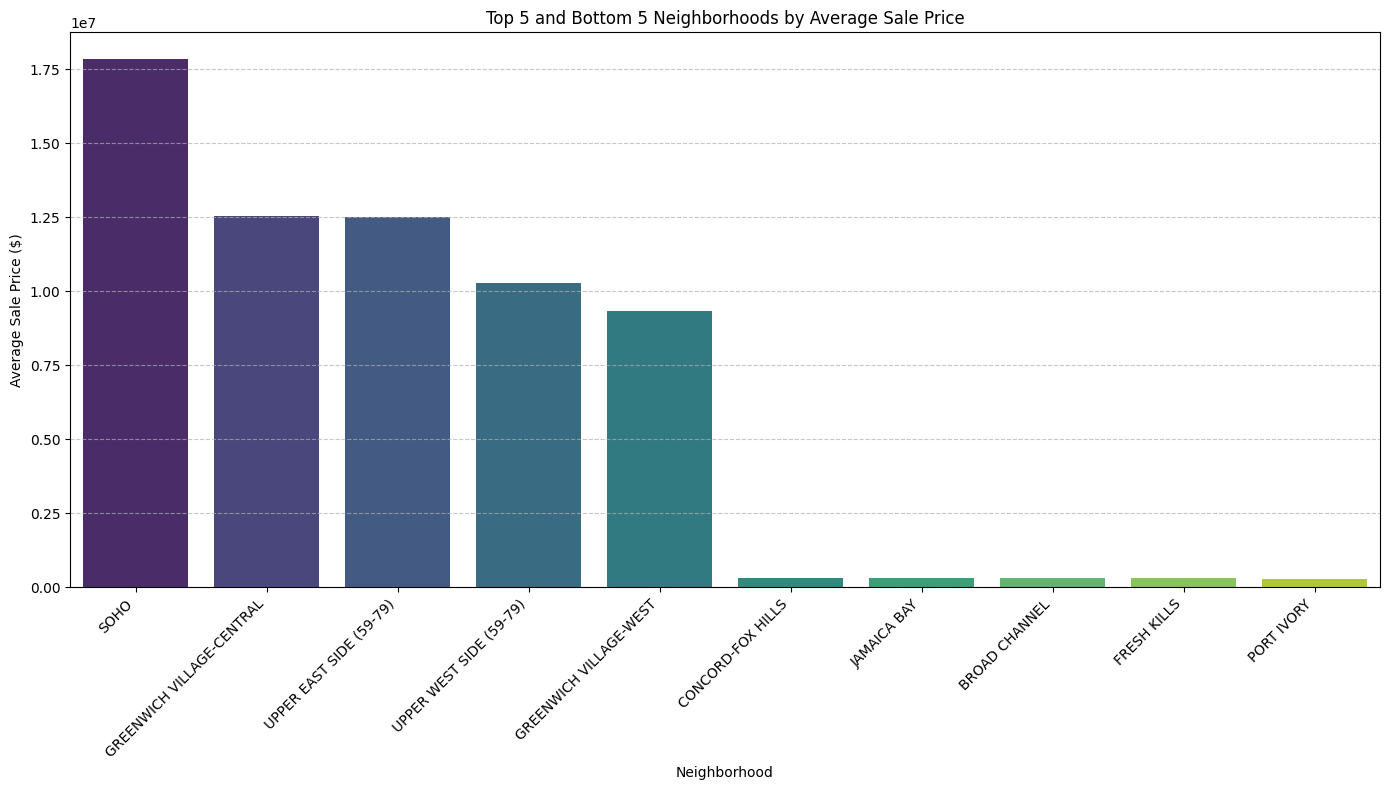

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 5 and bottom 5 neighborhoods by average sale price
top_5_neighborhoods = avg_price_by_neighborhood.head(5)
bottom_5_neighborhoods = avg_price_by_neighborhood.tail(5)

# Combine them for plotting
neighborhood_plot_data = pd.concat([top_5_neighborhoods, bottom_5_neighborhoods])

plt.figure(figsize=(14, 8))
sns.barplot(x=neighborhood_plot_data.index, y=neighborhood_plot_data.values, palette='viridis')
plt.title('Top 5 and Bottom 5 Neighborhoods by Average Sale Price')
plt.xlabel('Neighborhood')
plt.ylabel('Average Sale Price ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Correlation between Year Built and Sale Price: -0.10


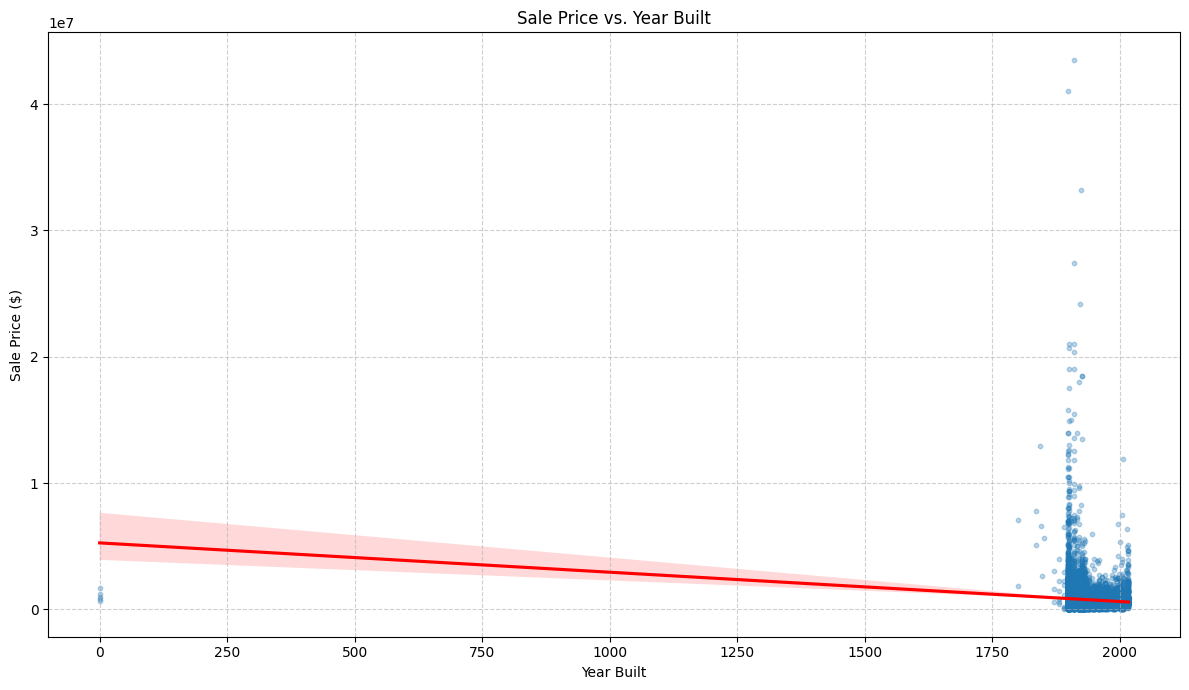


Average Sale Price by Year Built Category:
YEAR_BUILT_CATEGORY
Pre-1900     $1,498,626.86
1900-1939      $788,791.37
1940-1979      $649,047.20
Post-1980      $644,995.78
Name: SALE PRICE, dtype: object


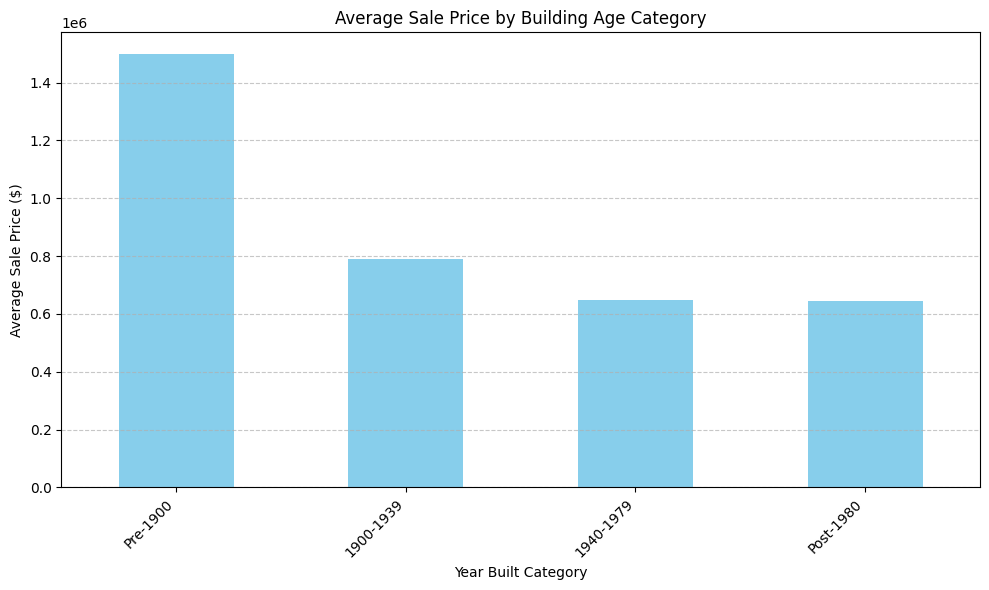

In [21]:
# Calculate the correlation between Year Built and Sale Price
correlation = df['YEAR BUILT'].corr(df['SALE PRICE'])
print(f"Correlation between Year Built and Sale Price: {correlation:.2f}")

# Visualize the relationship using a scatter plot with a regression line
plt.figure(figsize=(12, 7))
sns.regplot(x='YEAR BUILT', y='SALE PRICE', data=df, scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
plt.title('Sale Price vs. Year Built')
plt.xlabel('Year Built')
plt.ylabel('Sale Price ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Further investigate by grouping average sale price by year built (for specific years or bins)
# To make the trend clearer, let's look at average sale price in broad year built categories
def categorize_year_built(year):
    if year < 1900: return 'Pre-1900'
    elif year < 1940: return '1900-1939'
    elif year < 1980: return '1940-1979'
    else: return 'Post-1980'

df['YEAR_BUILT_CATEGORY'] = df['YEAR BUILT'].apply(categorize_year_built)

avg_price_by_year_category = df.groupby('YEAR_BUILT_CATEGORY')['SALE PRICE'].mean().reindex(['Pre-1900', '1900-1939', '1940-1979', 'Post-1980'])

print("\nAverage Sale Price by Year Built Category:")
print(avg_price_by_year_category.apply(lambda x: f'${x:,.2f}'))

plt.figure(figsize=(10, 6))
avg_price_by_year_category.plot(kind='bar', color='skyblue')
plt.title('Average Sale Price by Building Age Category')
plt.xlabel('Year Built Category')
plt.ylabel('Average Sale Price ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [22]:
display(df[['SALE PRICE', 'GROSS SQUARE FEET', 'PRICE_PER_SQFT']].head())

,SALE PRICE,GROSS SQUARE FEET,PRICE_PER_SQFT
206,7425000.0,3855.0,1926.070039
212,7750000.0,4978.0,1556.850141
214,8300000.0,3725.0,2228.187919
1791,3000000.0,3360.0,892.857143
1793,6800000.0,5920.0,1148.648649


Average Sale Price by Building Class Category (Residential Only):
BUILDING CLASS CATEGORY
03 THREE FAMILY DWELLINGS                      $1,012,637.32
02 TWO FAMILY DWELLINGS                          $806,950.40
01 ONE FAMILY DWELLINGS                          $671,863.69
Name: SALE PRICE, dtype: object


/tmp/ipykernel_6988/4113536327.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_by_building_type.index, y=avg_price_by_building_type.values, palette='coolwarm')


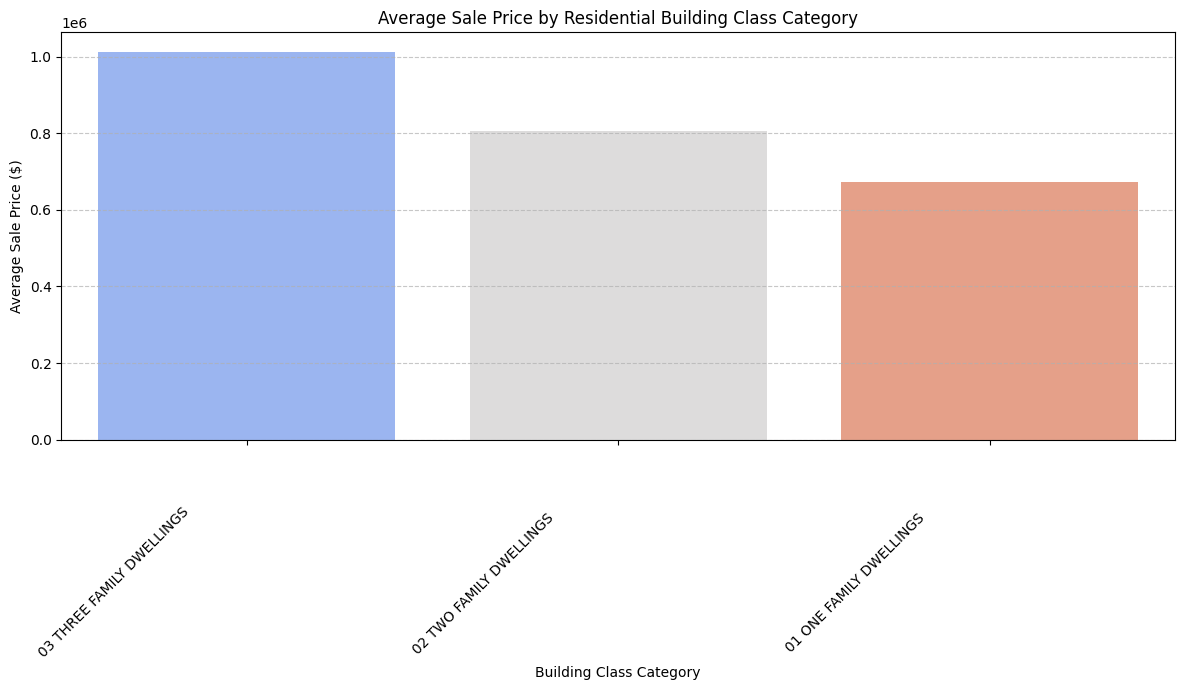

In [23]:
avg_price_by_building_type = df.groupby('BUILDING CLASS CATEGORY')['SALE PRICE'].mean().sort_values(ascending=False)

print("Average Sale Price by Building Class Category (Residential Only):")
print(avg_price_by_building_type.apply(lambda x: f'${x:,.2f}'))

plt.figure(figsize=(12, 7))
sns.barplot(x=avg_price_by_building_type.index, y=avg_price_by_building_type.values, palette='coolwarm')
plt.title('Average Sale Price by Residential Building Class Category')
plt.xlabel('Building Class Category')
plt.ylabel('Average Sale Price ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**SQL REQUIREMENTS**

In [24]:
# Mapping Borough numbers to County Names
borough_to_county = {
    1: 'New York County (Manhattan)',
    2: 'Bronx County',
    3: 'Kings County (Brooklyn)',
    4: 'Queens County',
    5: 'Richmond County (Staten Island)'
}

df['COUNTY_NAME'] = df['BOROUGH'].map(borough_to_county)

print("Added 'COUNTY_NAME' column to the DataFrame. First 5 rows:")
print(df[['BOROUGH', 'COUNTY_NAME', 'SALE PRICE']].head())


Added 'COUNTY_NAME' column to the DataFrame. First 5 rows:
      BOROUGH                  COUNTY_NAME  SALE PRICE
206         1  New York County (Manhattan)   7425000.0
212         1  New York County (Manhattan)   7750000.0
214         1  New York County (Manhattan)   8300000.0
1791        1  New York County (Manhattan)   3000000.0
1793        1  New York County (Manhattan)   6800000.0


In [25]:
# Calculate average and median sale price by county
avg_median_price_by_county = df.groupby('COUNTY_NAME')['SALE PRICE'].agg(['mean', 'median']).sort_values(by='mean', ascending=False)

print("\nAverage and Median Sale Price by County:")
print(avg_median_price_by_county)

# Display the results for clarity
print(f"\nFrom the analysis, we can see that {avg_median_price_by_county.index[0]} has the highest average sale price of ${avg_median_price_by_county.iloc[0]['mean']:,.2f},")
print(f"with a median sale price of ${avg_median_price_by_county.iloc[0]['median']:,.2f}.")
print(f"In contrast, {avg_median_price_by_county.index[-1]} has the lowest average sale price of ${avg_median_price_by_county.iloc[-1]['mean']:,.2f},")
print(f"with a median sale price of ${avg_median_price_by_county.iloc[-1]['median']:,.2f}.")



Average and Median Sale Price by County:
                                         mean     median
COUNTY_NAME                                             
New York County (Manhattan)      6.574102e+06  4650000.0
Kings County (Brooklyn)          9.943400e+05   800000.0
Queens County                    6.717441e+05   626223.0
Richmond County (Staten Island)  5.163823e+05   489000.0
Bronx County                     4.822053e+05   457157.0

From the analysis, we can see that New York County (Manhattan) has the highest average sale price of $6,574,101.59,
with a median sale price of $4,650,000.00.
In contrast, Bronx County has the lowest average sale price of $482,205.33,
with a median sale price of $457,157.00.


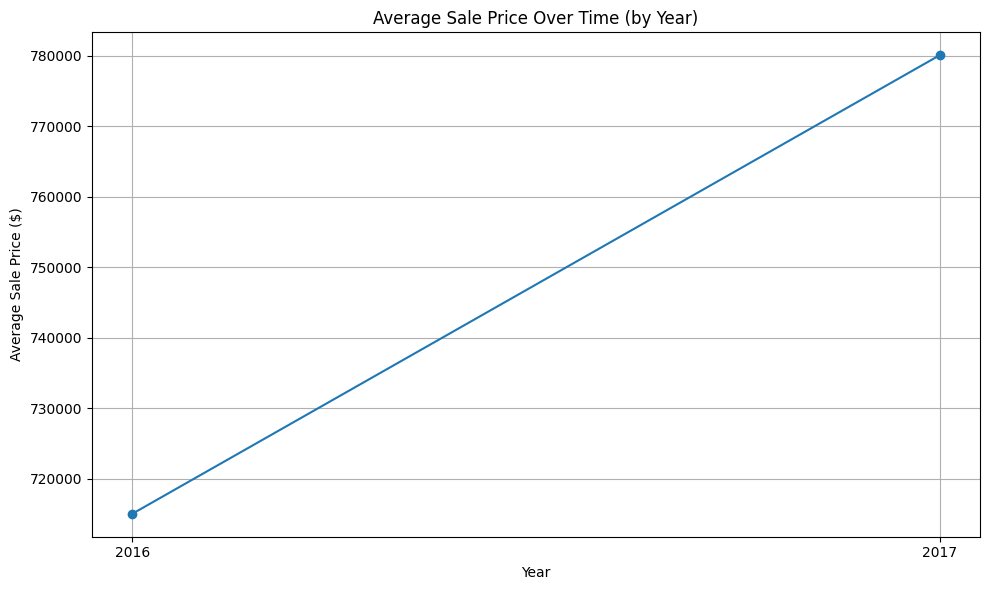

Average Sale Price by Year:
SALE_YEAR
2016    715014.006321
2017    780086.307572
Name: SALE PRICE, dtype: float64


In [26]:
df['SALE_YEAR'] = df['SALE DATE'].dt.year

avg_sale_price_by_year = df.groupby('SALE_YEAR')['SALE PRICE'].mean()

plt.figure(figsize=(10, 6))
avg_sale_price_by_year.plot(kind='line', marker='o')
plt.title('Average Sale Price Over Time (by Year)')
plt.xlabel('Year')
plt.ylabel('Average Sale Price ($)')
plt.grid(True)
plt.xticks(avg_sale_price_by_year.index)
plt.tight_layout()
plt.show()

print("Average Sale Price by Year:")
print(avg_sale_price_by_year)

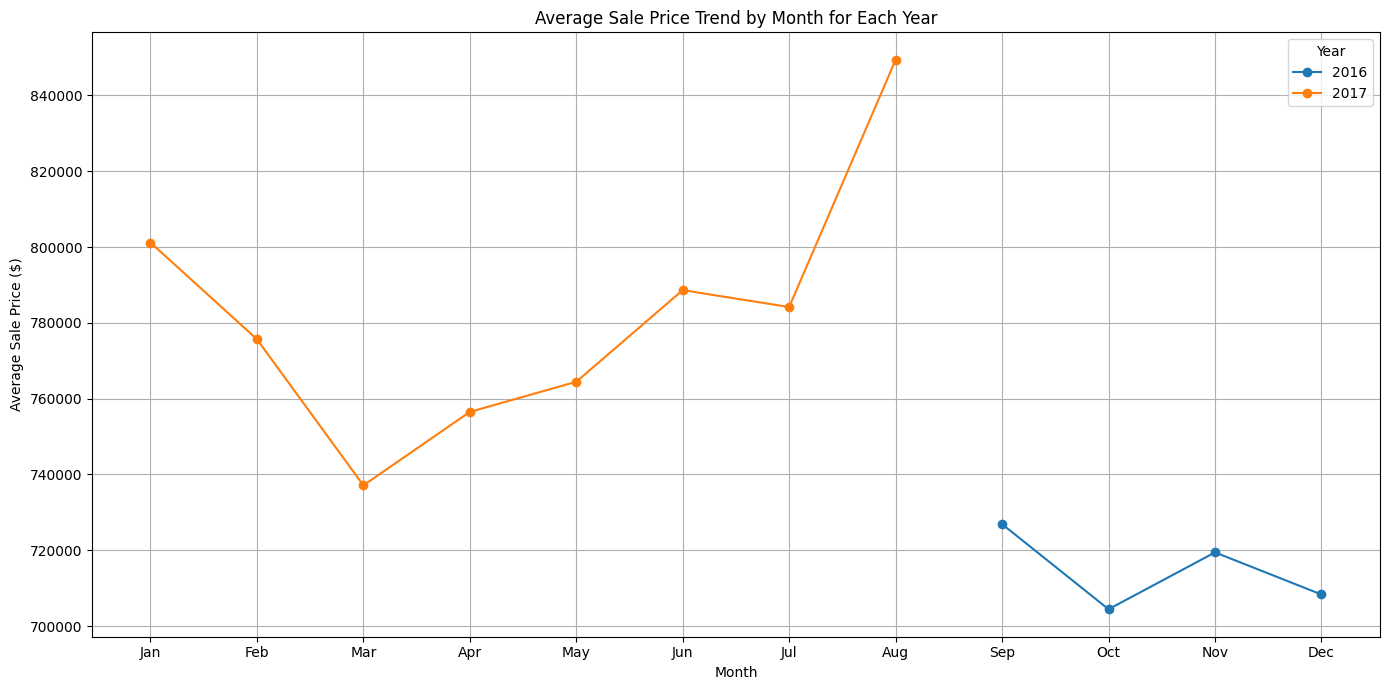

Average Sale Price by Year and Month:
SALE_YEAR                2016           2017
SALE_MONTH_NUM                              
1                         NaN  801200.355992
2                         NaN  775692.695513
3                         NaN  737134.048307
4                         NaN  756509.263933
5                         NaN  764467.351120
6                         NaN  788642.995752
7                         NaN  784178.868937
8                         NaN  849408.915053
9               726901.828037            NaN
10              704447.356965            NaN
11              719449.177905            NaN
12              708340.728571            NaN


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'SALE DATE' is in datetime format
df['SALE DATE'] = pd.to_datetime(df['SALE DATE'])

# Extract year and month number
df['SALE_YEAR'] = df['SALE DATE'].dt.year
df['SALE_MONTH_NUM'] = df['SALE DATE'].dt.month

# Calculate average sale price by year and month
avg_price_by_year_month = df.groupby(['SALE_YEAR', 'SALE_MONTH_NUM'])['SALE PRICE'].mean().unstack(level=0)

# Plotting the average sale price over time by month for each year
plt.figure(figsize=(14, 7))
avg_price_by_year_month.plot(kind='line', marker='o', ax=plt.gca())
plt.title('Average Sale Price Trend by Month for Each Year')
plt.xlabel('Month')
plt.ylabel('Average Sale Price ($)')
plt.grid(True)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Year')
plt.tight_layout()
plt.show()

print("Average Sale Price by Year and Month:")
print(avg_price_by_year_month)

Top 10 Most Expensive Neighborhoods by Average Sale Price:
NEIGHBORHOOD
SOHO                         $17,852,166.67
GREENWICH VILLAGE-CENTRAL    $12,538,249.90
UPPER EAST SIDE (59-79)      $12,517,403.85
UPPER WEST SIDE (59-79)      $10,267,857.14
GREENWICH VILLAGE-WEST        $9,314,444.74
UPPER EAST SIDE (79-96)       $8,938,163.75
CHELSEA                       $7,825,000.00
UPPER WEST SIDE (79-96)       $7,598,211.08
GRAMERCY                      $7,370,000.00
LITTLE ITALY                  $7,090,000.00
Name: SALE PRICE, dtype: object


/tmp/ipykernel_6988/4269598386.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_neighborhoods.index, y=top_10_neighborhoods.values, palette='viridis')


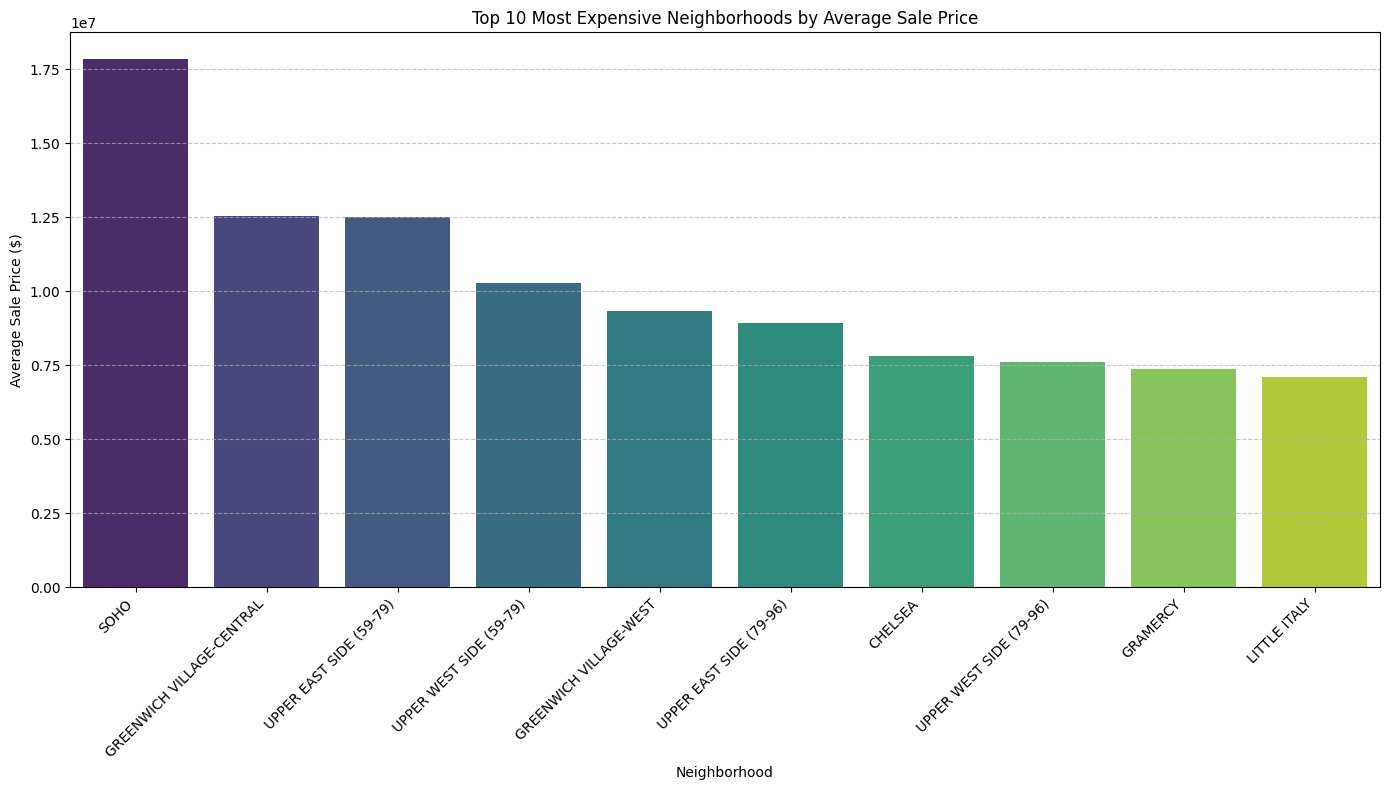

In [28]:
top_10_neighborhoods = avg_price_by_neighborhood.head(10)

print("Top 10 Most Expensive Neighborhoods by Average Sale Price:")
print(top_10_neighborhoods.apply(lambda x: f'${x:,.2f}'))

plt.figure(figsize=(14, 8))
sns.barplot(x=top_10_neighborhoods.index, y=top_10_neighborhoods.values, palette='viridis')
plt.title('Top 10 Most Expensive Neighborhoods by Average Sale Price')
plt.xlabel('Neighborhood')
plt.ylabel('Average Sale Price ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [29]:
avg_price_by_borough_year = df.groupby(['BOROUGH', 'SALE_YEAR'])['SALE PRICE'].mean().reset_index()

# Calculate the previous year's average sale price within each borough group
avg_price_by_borough_year['PREV_YEAR_SALE_PRICE'] = avg_price_by_borough_year.groupby('BOROUGH')['SALE PRICE'].shift(1)

# Calculate the year-over-year percentage change
avg_price_by_borough_year['YOY_PERCENT_CHANGE'] = ((avg_price_by_borough_year['SALE PRICE'] - avg_price_by_borough_year['PREV_YEAR_SALE_PRICE']) / avg_price_by_borough_year['PREV_YEAR_SALE_PRICE']) * 100

print("Year-over-Year Percentage Change in Average Sale Price by Borough:")
print(avg_price_by_borough_year)

# Filter for 2017 to see the actual YOY change values
yoy_change_2017 = avg_price_by_borough_year[avg_price_by_borough_year['SALE_YEAR'] == 2017]
print("\nYear-over-Year Percentage Change (2016 to 2017) by Borough:")
# Updated to use .map for string formatting to avoid FutureWarning
print(yoy_change_2017.dropna(subset=['YOY_PERCENT_CHANGE']).set_index('BOROUGH')[['YOY_PERCENT_CHANGE']].map(lambda x: f'{x:.2f}%'))

Year-over-Year Percentage Change in Average Sale Price by Borough:
   BOROUGH  SALE_YEAR    SALE PRICE  PREV_YEAR_SALE_PRICE  YOY_PERCENT_CHANGE
0        1       2016  5.444683e+06                   NaN                 NaN
1        1       2017  7.016391e+06          5.444683e+06           28.866852
2        2       2016  4.550737e+05                   NaN                 NaN
3        2       2017  4.968327e+05          4.550737e+05            9.176300
4        3       2016  9.485779e+05                   NaN                 NaN
5        3       2017  1.018438e+06          9.485779e+05            7.364751
6        4       2016  6.613834e+05                   NaN                 NaN
7        4       2017  6.773635e+05          6.613834e+05            2.416161
8        5       2016  5.058774e+05                   NaN                 NaN
9        5       2017  5.225682e+05          5.058774e+05            3.299378

Year-over-Year Percentage Change (2016 to 2017) by Borough:
        YOY_PE

Month-over-Month Percentage Change in Average Sale Price by Borough:
                           SALE PRICE  PREV_MONTH_SALE_PRICE  \
BOROUGH SALE_MONTH_YEAR                                        
1       2016-10          5.514750e+06           5.777059e+06   
        2016-11          6.747303e+06           5.514750e+06   
        2016-12          3.805500e+06           6.747303e+06   
        2017-01          7.548664e+06           3.805500e+06   
        2017-02          9.064600e+06           7.548664e+06   
        2017-03          6.451471e+06           9.064600e+06   
        2017-04          9.615469e+06           6.451471e+06   
        2017-05          7.585000e+06           9.615469e+06   
        2017-06          5.906738e+06           7.585000e+06   
        2017-07          6.416979e+06           5.906738e+06   
        2017-08          4.802146e+06           6.416979e+06   
2       2016-10          4.373862e+05           4.527313e+05   
        2016-11          4.674773e+

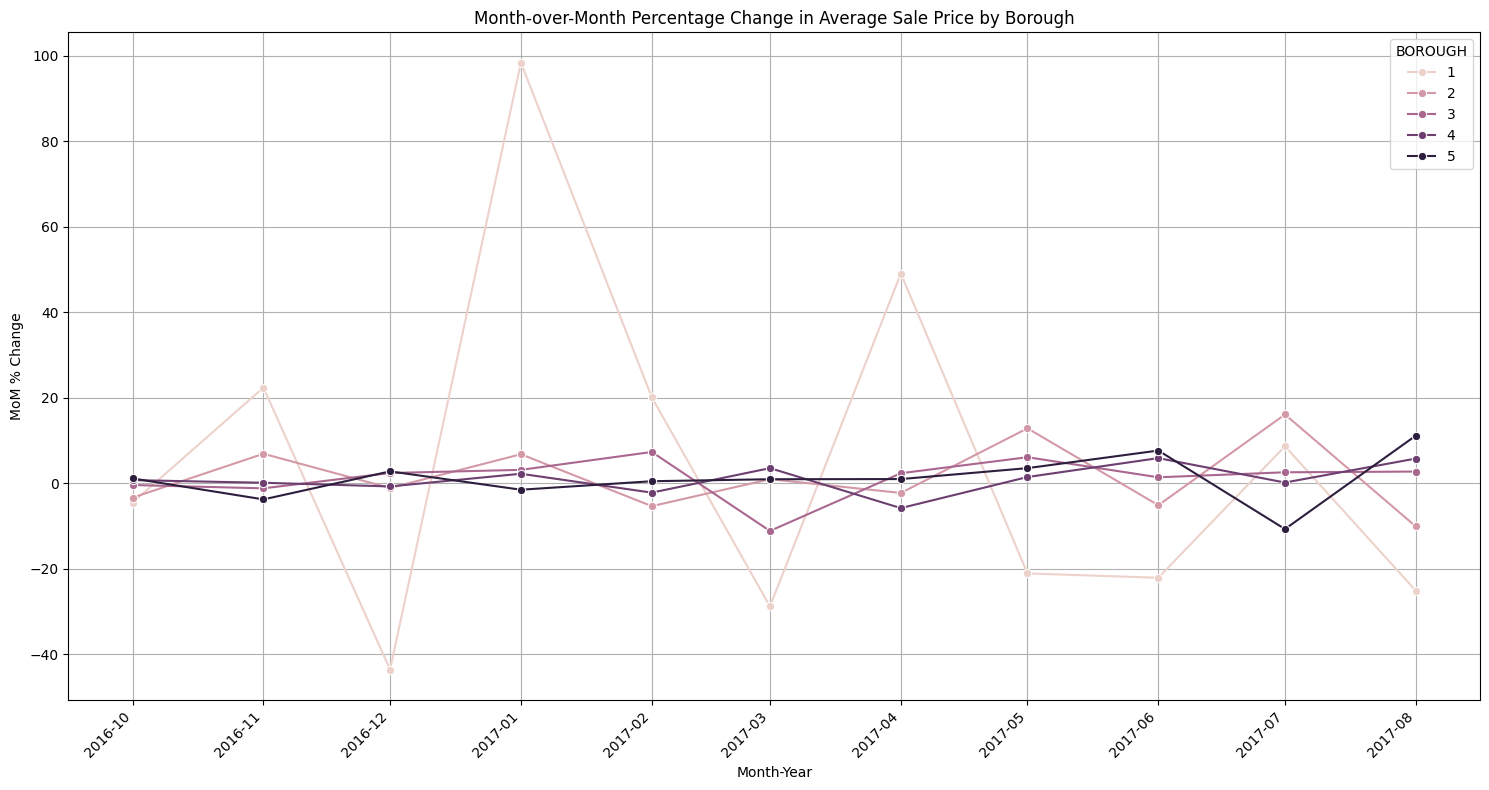

In [30]:
avg_price_by_borough_month = df.groupby(['BOROUGH', 'SALE_MONTH_YEAR'])['SALE PRICE'].mean().reset_index()

# Sort by borough and month to ensure correct shifting
avg_price_by_borough_month = avg_price_by_borough_month.sort_values(by=['BOROUGH', 'SALE_MONTH_YEAR'])

# Calculate the previous month's average sale price within each borough group
avg_price_by_borough_month['PREV_MONTH_SALE_PRICE'] = avg_price_by_borough_month.groupby('BOROUGH')['SALE PRICE'].shift(1)

# Calculate the month-over-month percentage change
avg_price_by_borough_month['MOM_PERCENT_CHANGE'] = ((avg_price_by_borough_month['SALE PRICE'] - avg_price_by_borough_month['PREV_MONTH_SALE_PRICE']) / avg_price_by_borough_month['PREV_MONTH_SALE_PRICE']) * 100

print("Month-over-Month Percentage Change in Average Sale Price by Borough:")
print(avg_price_by_borough_month.dropna(subset=['MOM_PERCENT_CHANGE']).set_index(['BOROUGH', 'SALE_MONTH_YEAR']))

# Convert SALE_MONTH_YEAR to datetime for plotting
avg_price_by_borough_month['SALE_MONTH_YEAR_DT'] = avg_price_by_borough_month['SALE_MONTH_YEAR'].dt.to_timestamp()

# Visualize the Month-over-Month percentage change for each borough
plt.figure(figsize=(15, 8))
sns.lineplot(data=avg_price_by_borough_month, x='SALE_MONTH_YEAR_DT', y='MOM_PERCENT_CHANGE', hue='BOROUGH', marker='o')
plt.title('Month-over-Month Percentage Change in Average Sale Price by Borough')
plt.xlabel('Month-Year')
plt.ylabel('MoM % Change')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [31]:
# Define the conditions for the era bands
conditions = [
    df['YEAR BUILT'] < 1950,
    (df['YEAR BUILT'] >= 1950) & (df['YEAR BUILT'] <= 2000),
    df['YEAR BUILT'] > 2000
]

# Define the choices (era band labels)
choices = ['pre-1950', '1950–2000', 'post-2000']

# Create the new 'BUILDING_ERA' column using numpy.select
df['BUILDING_ERA'] = np.select(conditions, choices, default='Unknown')

print("Distribution of properties by Building Era:")
print(df['BUILDING_ERA'].value_counts())

print("\nFirst 5 rows with the new 'BUILDING_ERA' column:")
print(df[['YEAR BUILT', 'BUILDING_ERA']].head())

Distribution of properties by Building Era:
BUILDING_ERA
pre-1950     15680
1950–2000     7108
post-2000     1880
Name: count, dtype: int64

First 5 rows with the new 'BUILDING_ERA' column:
      YEAR BUILT BUILDING_ERA
206         1901     pre-1950
212         1920     pre-1950
214         1901     pre-1950
1791        1900     pre-1950
1793        1899     pre-1950


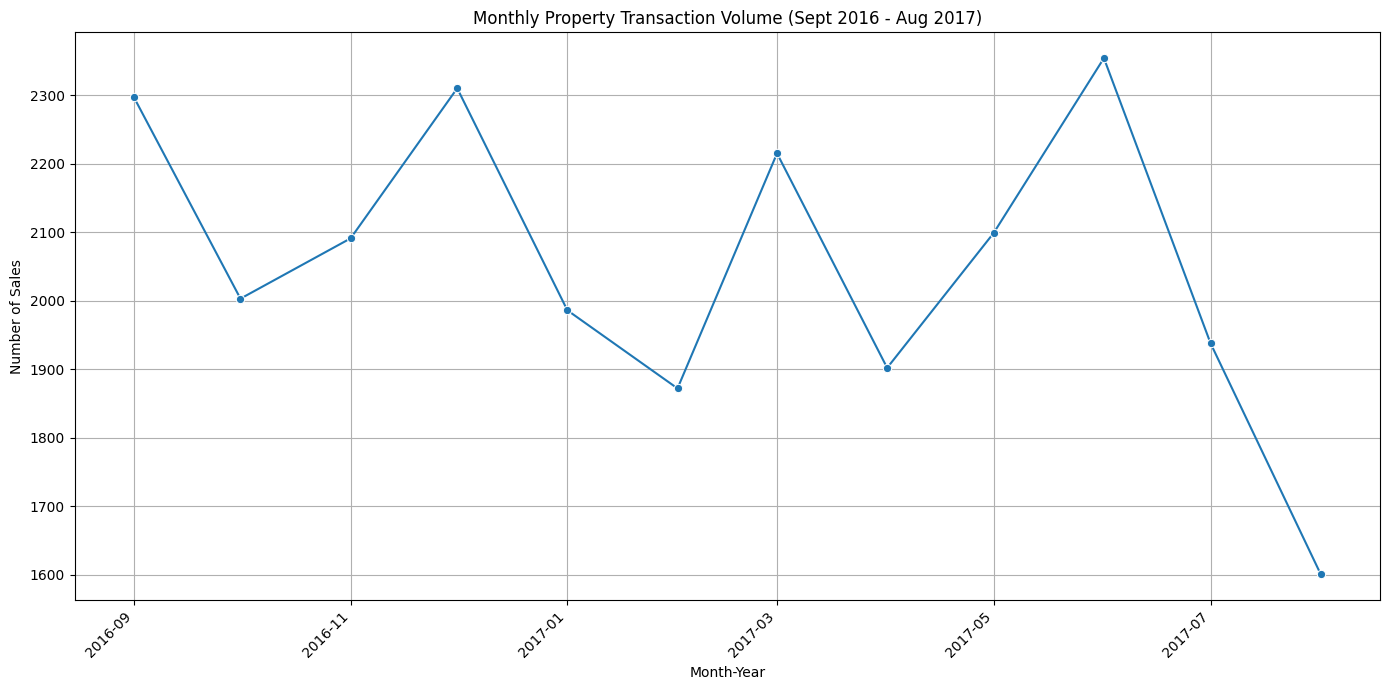

Monthly Property Transaction Volume:
                 Transaction Volume SALE_MONTH_YEAR_DT
SALE_MONTH_YEAR                                       
2016-09                        2297         2016-09-01
2016-10                        2003         2016-10-01
2016-11                        2091         2016-11-01
2016-12                        2310         2016-12-01
2017-01                        1986         2017-01-01
2017-02                        1872         2017-02-01
2017-03                        2215         2017-03-01
2017-04                        1902         2017-04-01
2017-05                        2099         2017-05-01
2017-06                        2354         2017-06-01
2017-07                        1938         2017-07-01
2017-08                        1601         2017-08-01

The month with the highest transaction volume was 2017-06 with 2354 sales.
The month with the lowest transaction volume was 2017-08 with 1601 sales.


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate transaction volume by month
monthly_transaction_volume = df.groupby('SALE_MONTH_YEAR').size().reset_index(name='Transaction Volume')

# Convert SALE_MONTH_YEAR to datetime for plotting
monthly_transaction_volume['SALE_MONTH_YEAR_DT'] = monthly_transaction_volume['SALE_MONTH_YEAR'].dt.to_timestamp()

# Plotting the transaction volume over time by month
plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_transaction_volume, x='SALE_MONTH_YEAR_DT', y='Transaction Volume', marker='o')
plt.title('Monthly Property Transaction Volume (Sept 2016 - Aug 2017)')
plt.xlabel('Month-Year')
plt.ylabel('Number of Sales')
plt.grid(True)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Monthly Property Transaction Volume:")
print(monthly_transaction_volume.set_index('SALE_MONTH_YEAR'))

# Identify months with highest and lowest volume
highest_volume_month = monthly_transaction_volume.loc[monthly_transaction_volume['Transaction Volume'].idxmax()]
lowest_volume_month = monthly_transaction_volume.loc[monthly_transaction_volume['Transaction Volume'].idxmin()]

print(f"\nThe month with the highest transaction volume was {highest_volume_month['SALE_MONTH_YEAR']} with {highest_volume_month['Transaction Volume']} sales.")
print(f"The month with the lowest transaction volume was {lowest_volume_month['SALE_MONTH_YEAR']} with {lowest_volume_month['Transaction Volume']} sales.")

In [33]:
avg_price_by_borough = df.groupby('BOROUGH')['SALE PRICE'].mean().rename('BOROUGH_AVG_SALE_PRICE')
df = df.merge(avg_price_by_borough, on='BOROUGH', how='left')
df['LUXURY_THRESHOLD'] = 2 * df['BOROUGH_AVG_SALE_PRICE']
df['IS_LUXURY'] = df['SALE PRICE'] > df['LUXURY_THRESHOLD']

print(f"Number of luxury properties (more than 2x borough average): {df['IS_LUXURY'].sum()}")
print("\nFirst 5 rows with new 'IS_LUXURY' column:")
print(df[['BOROUGH', 'SALE PRICE', 'BOROUGH_AVG_SALE_PRICE', 'LUXURY_THRESHOLD', 'IS_LUXURY']].head())

Number of luxury properties (more than 2x borough average): 1166

First 5 rows with new 'IS_LUXURY' column:
   BOROUGH  SALE PRICE  BOROUGH_AVG_SALE_PRICE  LUXURY_THRESHOLD  IS_LUXURY
0        1   7425000.0            6.574102e+06      1.314820e+07      False
1        1   7750000.0            6.574102e+06      1.314820e+07      False
2        1   8300000.0            6.574102e+06      1.314820e+07      False
3        1   3000000.0            6.574102e+06      1.314820e+07      False
4        1   6800000.0            6.574102e+06      1.314820e+07      False


In [34]:
luxury_properties = df[df['IS_LUXURY'] == True]
print(f"Displaying the first 20 luxury properties (out of {len(luxury_properties)} total luxury properties):")
display(luxury_properties[['BOROUGH', 'NEIGHBORHOOD', 'SALE PRICE', 'GROSS SQUARE FEET', 'PRICE_PER_SQFT', 'BUILDING CLASS CATEGORY']].head(20))

Displaying the first 20 luxury properties (out of 1166 total luxury properties):


,BOROUGH,NEIGHBORHOOD,SALE PRICE,GROSS SQUARE FEET,PRICE_PER_SQFT,BUILDING CLASS CATEGORY
10,1,GRAMERCY,13500000.0,6496.0,2078.201970,03 THREE FAMILY DWELLINGS
13,1,GREENWICH VILLAGE-CENTRAL,14000000.0,3960.0,3535.353535,01 ONE FAMILY DWELLINGS
14,1,GREENWICH VILLAGE-CENTRAL,20650000.0,7000.0,2950.000000,01 ONE FAMILY DWELLINGS
15,1,GREENWICH VILLAGE-CENTRAL,21000000.0,6202.0,3386.004515,01 ONE FAMILY DWELLINGS
25,1,GREENWICH VILLAGE-WEST,19000000.0,4073.0,4664.866192,01 ONE FAMILY DWELLINGS
32,1,GREENWICH VILLAGE-WEST,14000000.0,6925.0,2021.660650,02 TWO FAMILY DWELLINGS
34,1,GREENWICH VILLAGE-WEST,15000000.0,3600.0,4166.666667,02 TWO FAMILY DWELLINGS
39,1,GREENWICH VILLAGE-WEST,27400000.0,5750.0,4765.217391,03 THREE FAMILY DWELLINGS
126,1,SOHO,43500000.0,7000.0,6214.285714,02 TWO FAMILY DWELLINGS
128,1,UPPER EAST SIDE (59-79),24175000.0,9600.0,2518.229167,01 ONE FAMILY DWELLINGS


**DASHBOARD REQUIREMENT**

In [35]:
print("**Dashboard Key Performance Indicators (KPIs)**")
print("---------------------------------------------------")

# 1. Total Sales
total_sales = df.shape[0]
print(f"Total Sales: {total_sales:,}")

# 2. Average Sale Price
avg_sale_price = df['SALE PRICE'].mean()
print(f"Average Sale Price: ${avg_sale_price:,.2f}")

# 3. Average Price per Square Foot
avg_price_per_sqft = df['PRICE_PER_SQFT'].mean()
print(f"Average Price per Square Foot: ${avg_price_per_sqft:,.2f}")

# 4. Most Expensive Borough (by average sale price)
# Re-using previously calculated values or recalculating if not available in current state
# (assuming avg_price_by_borough from previous execution is available and accurate)
if 'avg_price_by_borough' in locals():
    most_expensive_borough = avg_price_by_borough.index[0]
    most_expensive_borough_price = avg_price_by_borough.iloc[0]
else:
    # Fallback if the variable is not found (though it should be in this notebook state)
    avg_price_by_borough = df.groupby('BOROUGH')['SALE PRICE'].mean().sort_values(ascending=False)
    most_expensive_borough = avg_price_by_borough.index[0]
    most_expensive_borough_price = avg_price_by_borough.iloc[0]

# Mapping Borough numbers to County Names for better readability
borough_to_county = {
    1: 'New York County (Manhattan)',
    2: 'Bronx County',
    3: 'Kings County (Brooklyn)',
    4: 'Queens County',
    5: 'Richmond County (Staten Island)'
}
most_expensive_borough_name = borough_to_county.get(most_expensive_borough, f'Borough {most_expensive_borough}')

print(f"Most Expensive Borough (by avg sale price): {most_expensive_borough_name} (Avg: ${most_expensive_borough_price:,.2f})")


**Dashboard Key Performance Indicators (KPIs)**
---------------------------------------------------
Total Sales: 24,668
Average Sale Price: $757,133.73
Average Price per Square Foot: $398.93
Most Expensive Borough (by avg sale price): New York County (Manhattan) (Avg: $6,574,101.59)


/tmp/ipykernel_6988/945025358.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_by_borough.index, y=avg_price_by_borough.values, palette='viridis')


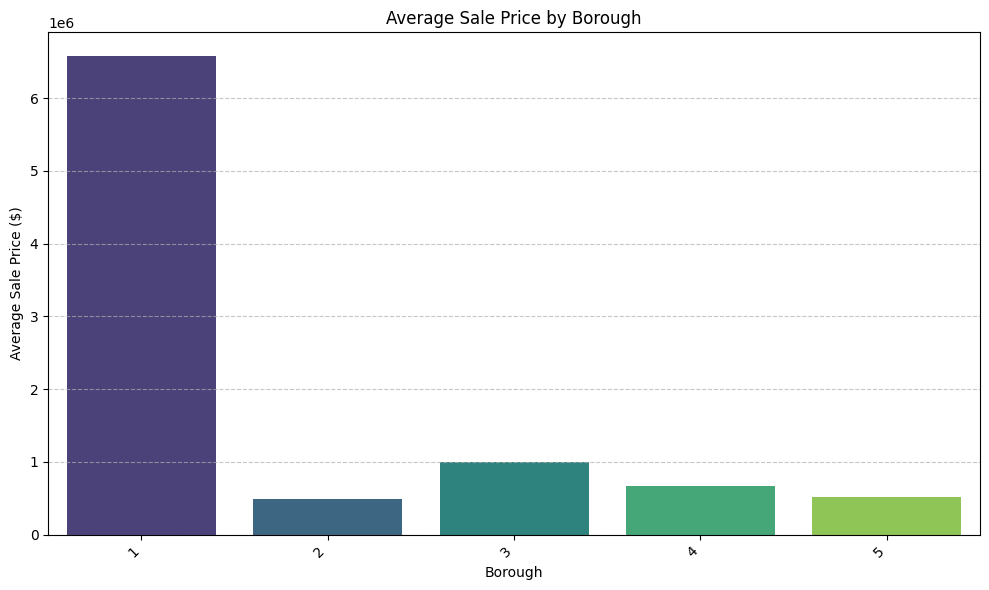

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming avg_price_by_borough is already calculated and available from previous steps
# If not, uncomment the following line:
# avg_price_by_borough = df.groupby('BOROUGH')['SALE PRICE'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_price_by_borough.index, y=avg_price_by_borough.values, palette='viridis')
plt.title('Average Sale Price by Borough')
plt.xlabel('Borough')
plt.ylabel('Average Sale Price ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Price trend over time — line chart by year

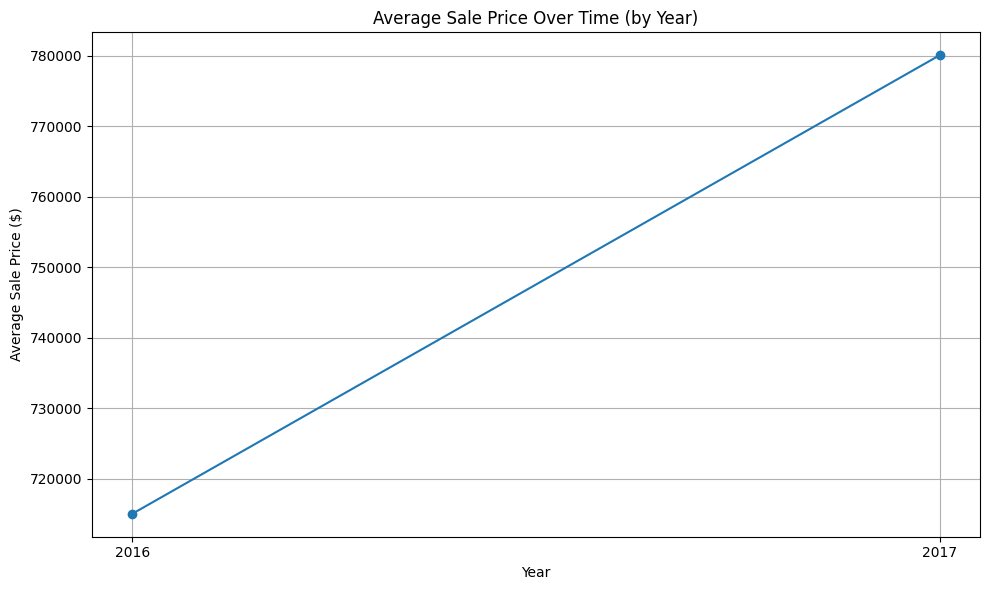

Average Sale Price by Year:
SALE_YEAR
2016    715014.006321
2017    780086.307572
Name: SALE PRICE, dtype: float64


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming avg_sale_price_by_year is already calculated and available
# If not, it can be recalculated as:
# df['SALE_YEAR'] = df['SALE DATE'].dt.year
# avg_sale_price_by_year = df.groupby('SALE_YEAR')['SALE PRICE'].mean()

plt.figure(figsize=(10, 6))
avg_sale_price_by_year.plot(kind='line', marker='o')
plt.title('Average Sale Price Over Time (by Year)')
plt.xlabel('Year')
plt.ylabel('Average Sale Price ($)')
plt.grid(True)
plt.xticks(avg_sale_price_by_year.index)
plt.tight_layout()
plt.show()

print("Average Sale Price by Year:")
print(avg_sale_price_by_year)

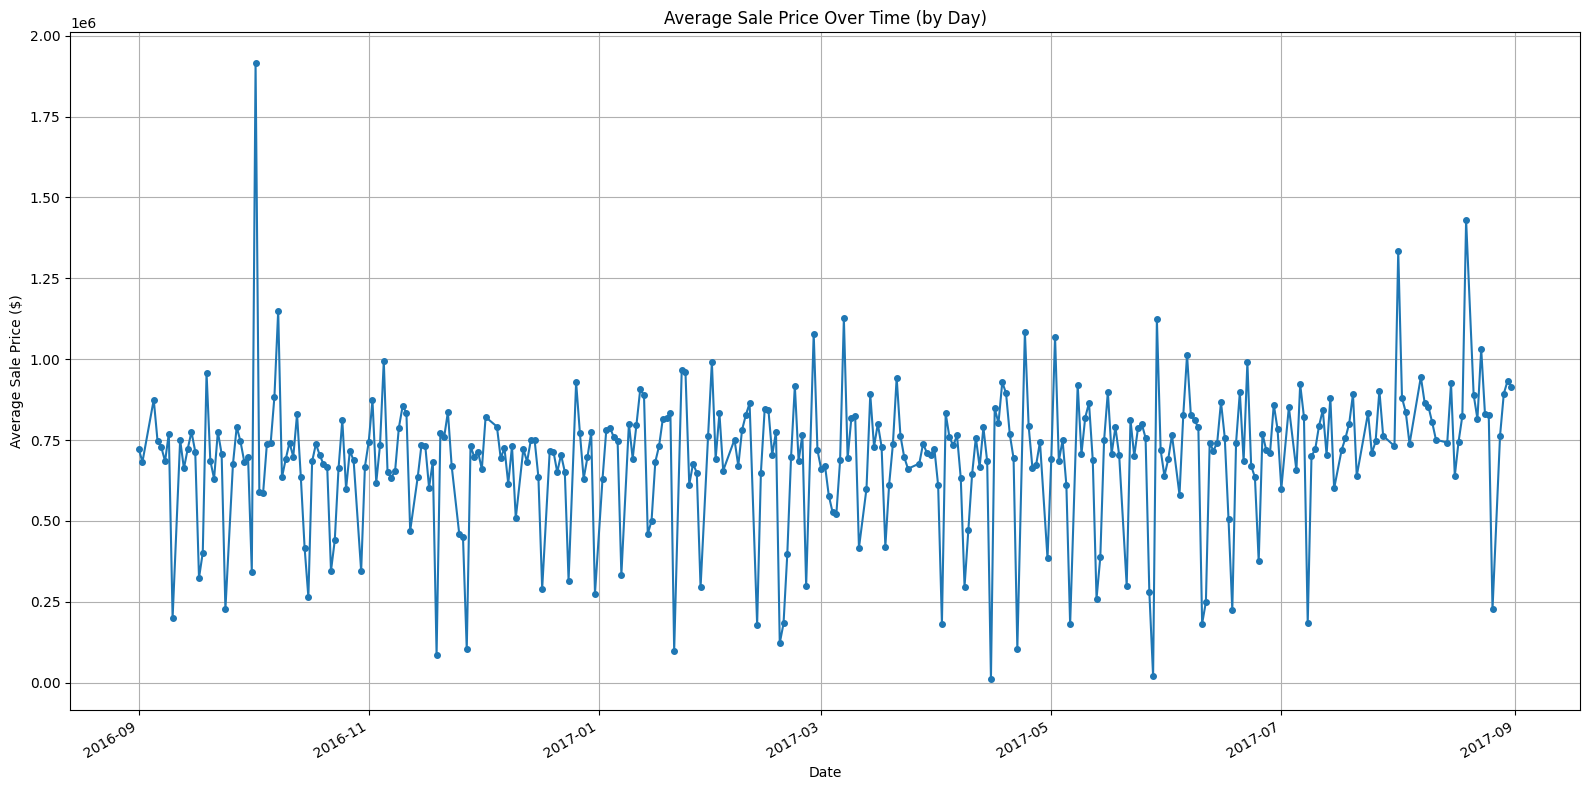

Average Sale Price by Day (first 5 and last 5 entries):
SALE DATE
2016-09-01    723741.178218
2016-09-02    682260.746667
2016-09-05    875000.000000
2016-09-06    748020.500000
2016-09-07    727842.913043
Name: SALE PRICE, dtype: float64
SALE DATE
2017-08-26    226726.000000
2017-08-28    763580.068182
2017-08-29    893782.113636
2017-08-30    932967.769231
2017-08-31    914331.600000
Name: SALE PRICE, dtype: float64


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average sale price by day
avg_sale_price_by_day = df.groupby('SALE DATE')['SALE PRICE'].mean()

# Plotting the average sale price over time by day
plt.figure(figsize=(16, 8))
avg_sale_price_by_day.plot(kind='line', marker='o', linestyle='-', markersize=4)
plt.title('Average Sale Price Over Time (by Day)')
plt.xlabel('Date')
plt.ylabel('Average Sale Price ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

print("Average Sale Price by Day (first 5 and last 5 entries):")
print(avg_sale_price_by_day.head())
print(avg_sale_price_by_day.tail())

Top 15 neighbourhoods by price — horizontal bar chart

/tmp/ipykernel_6988/2333369345.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_neighborhoods.values, y=top_15_neighborhoods.index, palette='magma')


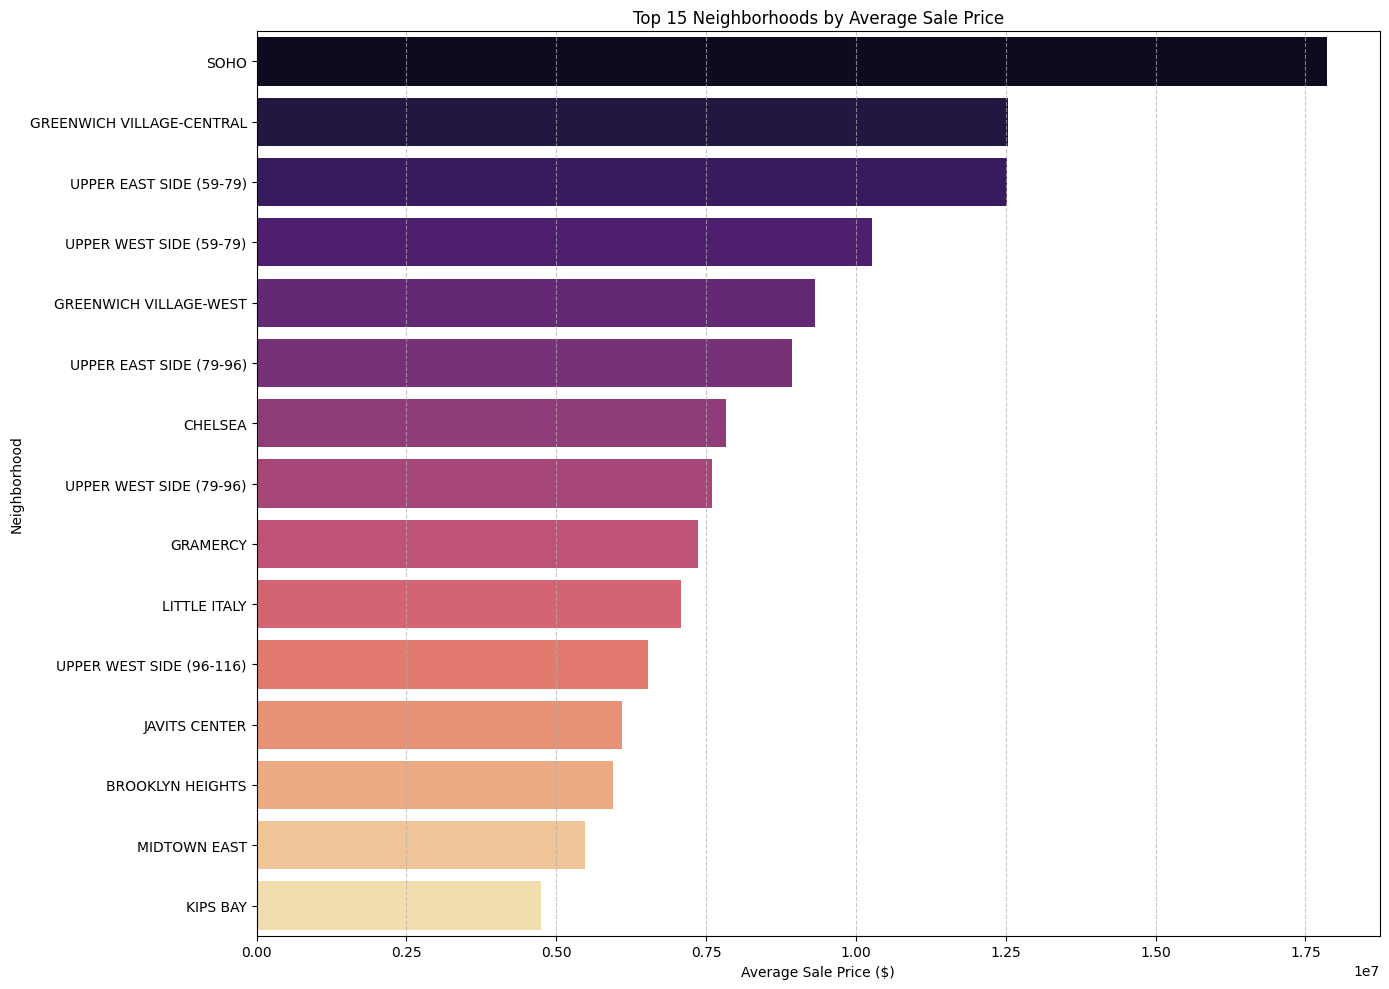

Top 15 Most Expensive Neighborhoods by Average Sale Price:
NEIGHBORHOOD
SOHO                         $17,852,166.67
GREENWICH VILLAGE-CENTRAL    $12,538,249.90
UPPER EAST SIDE (59-79)      $12,517,403.85
UPPER WEST SIDE (59-79)      $10,267,857.14
GREENWICH VILLAGE-WEST        $9,314,444.74
UPPER EAST SIDE (79-96)       $8,938,163.75
CHELSEA                       $7,825,000.00
UPPER WEST SIDE (79-96)       $7,598,211.08
GRAMERCY                      $7,370,000.00
LITTLE ITALY                  $7,090,000.00
UPPER WEST SIDE (96-116)      $6,530,000.00
JAVITS CENTER                 $6,100,000.00
BROOKLYN HEIGHTS              $5,954,944.44
MIDTOWN EAST                  $5,480,000.00
KIPS BAY                      $4,750,000.00
Name: SALE PRICE, dtype: object


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 15 neighborhoods by average sale price
top_15_neighborhoods = avg_price_by_neighborhood.head(15)

plt.figure(figsize=(14, 10))
sns.barplot(x=top_15_neighborhoods.values, y=top_15_neighborhoods.index, palette='magma')
plt.title('Top 15 Neighborhoods by Average Sale Price')
plt.xlabel('Average Sale Price ($)')
plt.ylabel('Neighborhood')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Top 15 Most Expensive Neighborhoods by Average Sale Price:")
print(top_15_neighborhoods.apply(lambda x: f'${x:,.2f}'))

Price per sqft heatmap by borough — if available, use a map visual

/tmp/ipykernel_6988/173426386.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_data.index, y=plot_data.values, palette='plasma')


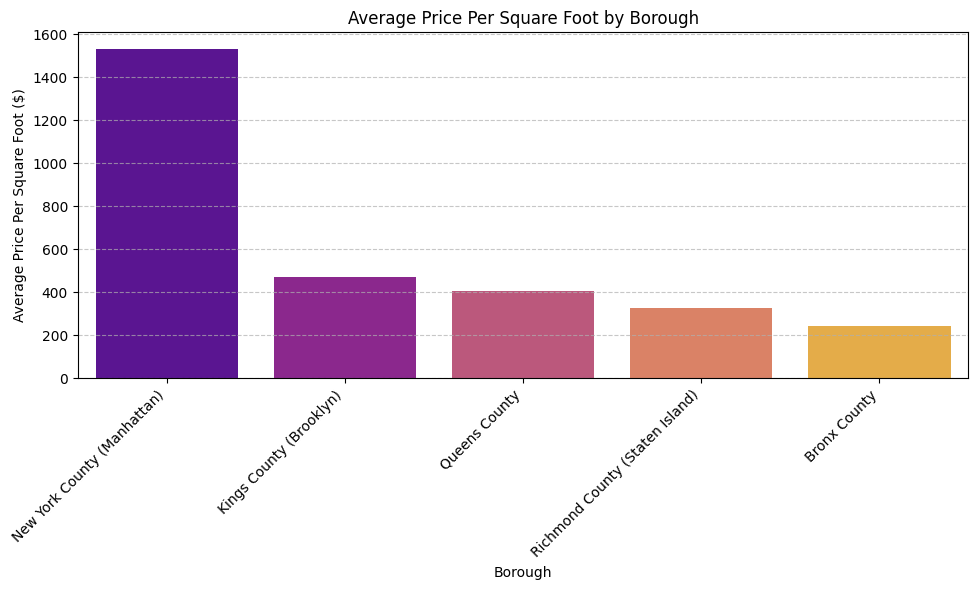

Average Price Per Square Foot by Borough (with names):
COUNTY_NAME
New York County (Manhattan)        $1,531.36
Kings County (Brooklyn)              $469.62
Queens County                        $407.53
Richmond County (Staten Island)      $325.29
Bronx County                         $242.85
Name: PRICE_PER_SQFT, dtype: object


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mapping Borough numbers to County Names for better readability
borough_to_county = {
    1: 'Manhattan',
    2: 'Bronx',
    3: 'Brooklyn',
    4: 'Queens',
    5: 'Staten Island'
}

# Assuming avg_price_sqft_by_borough is already calculated and available
# If not, it can be recalculated as:
# df['PRICE_PER_SQFT'] = df['SALE PRICE'] / df['GROSS SQUARE FEET']
# avg_price_sqft_by_borough = df.groupby('BOROUGH')['PRICE_PER_SQFT'].mean().sort_values(ascending=False)

# Apply the mapping to the index for plotting
plot_data = avg_price_sqft_by_borough.rename(index=borough_to_county)

plt.figure(figsize=(10, 6))
sns.barplot(x=plot_data.index, y=plot_data.values, palette='plasma')
plt.title('Average Price Per Square Foot by Borough')
plt.xlabel('Borough')
plt.ylabel('Average Price Per Square Foot ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Average Price Per Square Foot by Borough (with names):")
print(plot_data.apply(lambda x: f'${x:,.2f}'))

Building type vs avg price — bar chart

Transaction volume by month — bar chart showing seasonal pattern

/tmp/ipykernel_6988/329135054.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='SALE_MONTH_YEAR_DT', y='Transaction Volume', data=monthly_transaction_volume, palette='viridis')


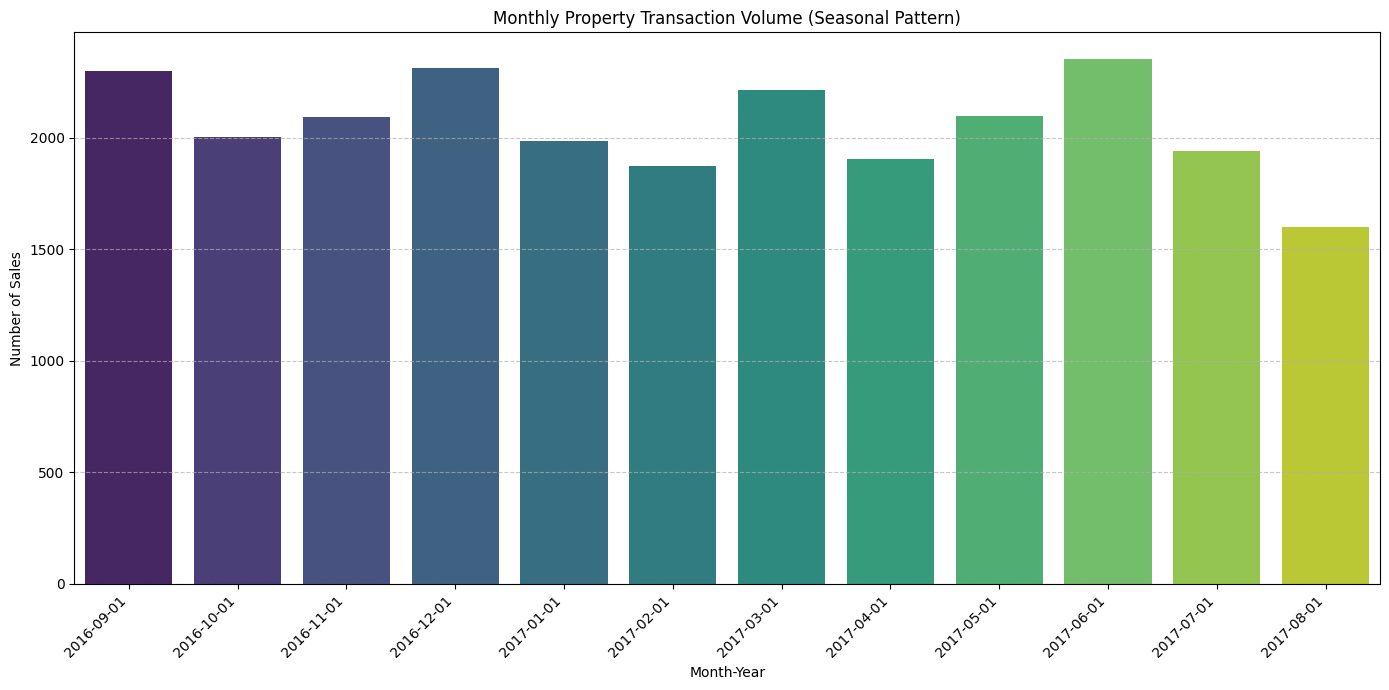

Monthly Property Transaction Volume:
                 Transaction Volume SALE_MONTH_YEAR_DT
SALE_MONTH_YEAR                                       
2016-09                        2297         2016-09-01
2016-10                        2003         2016-10-01
2016-11                        2091         2016-11-01
2016-12                        2310         2016-12-01
2017-01                        1986         2017-01-01
2017-02                        1872         2017-02-01
2017-03                        2215         2017-03-01
2017-04                        1902         2017-04-01
2017-05                        2099         2017-05-01
2017-06                        2354         2017-06-01
2017-07                        1938         2017-07-01
2017-08                        1601         2017-08-01


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure monthly_transaction_volume is available (re-calculate if needed)
# monthly_transaction_volume = df.groupby('SALE_MONTH_YEAR').size().reset_index(name='Transaction Volume')
# monthly_transaction_volume['SALE_MONTH_YEAR_DT'] = monthly_transaction_volume['SALE_MONTH_YEAR'].dt.to_timestamp()

plt.figure(figsize=(14, 7))
sns.barplot(x='SALE_MONTH_YEAR_DT', y='Transaction Volume', data=monthly_transaction_volume, palette='viridis')
plt.title('Monthly Property Transaction Volume (Seasonal Pattern)')
plt.xlabel('Month-Year')
plt.ylabel('Number of Sales')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Monthly Property Transaction Volume:")
print(monthly_transaction_volume.set_index('SALE_MONTH_YEAR'))

**CROWN METRIC**


The borough with the strongest year-over-year price growth (2016-2017) is Borough 1.0 with a 28.87% increase.

With only two years of data (2016 and 2017), it's difficult to assess 'consistency' comprehensively. However, the borough with the strongest growth in this period (Borough 1 - Manhattan) showed the highest appreciation.


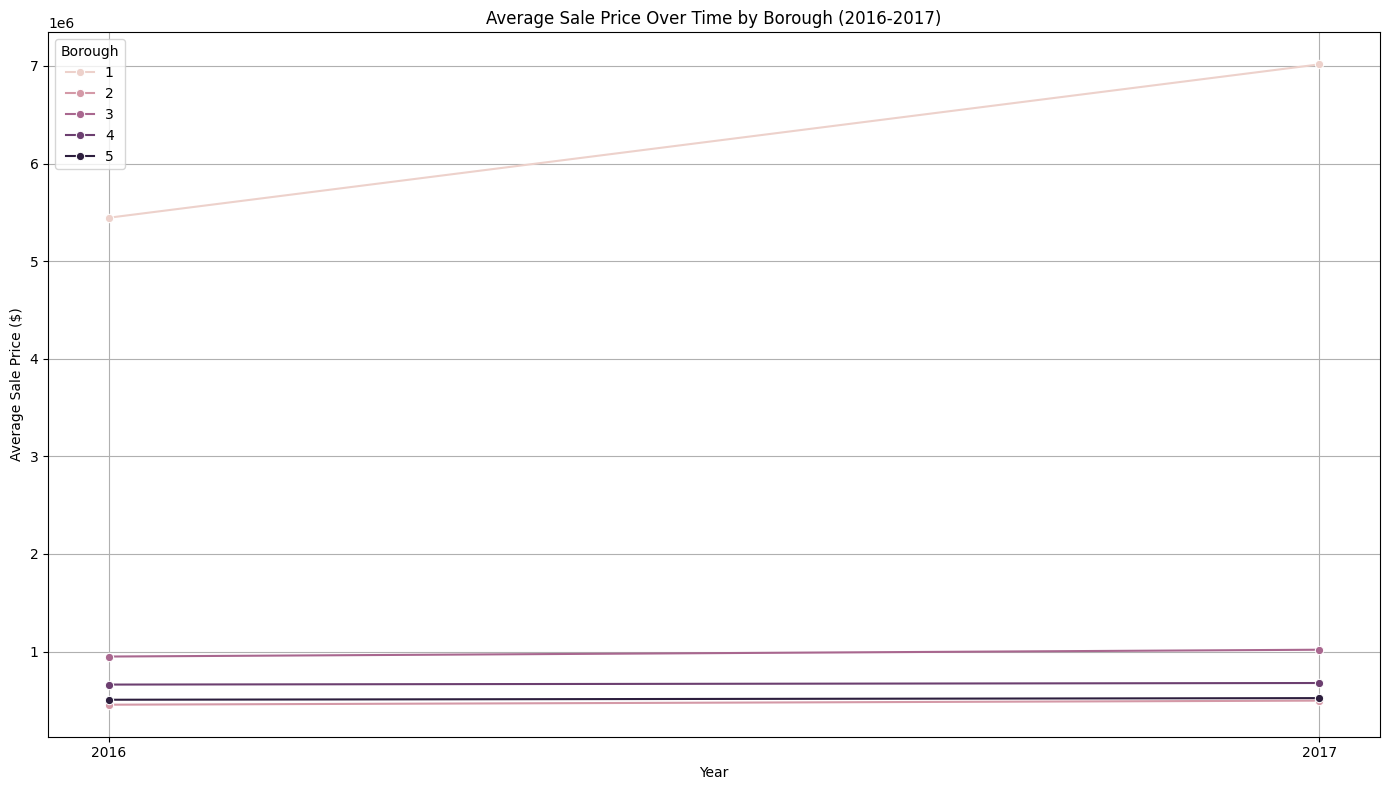


Average Sale Price by Borough and Year:
BOROUGH               1              2             3              4  \
SALE_YEAR                                                             
2016       5.444683e+06  455073.742743  9.485779e+05  661383.380478   
2017       7.016391e+06  496832.674582  1.018438e+06  677363.470443   

BOROUGH                5  
SALE_YEAR                 
2016       505877.426954  
2017       522568.235078  


In [42]:
# Identify the borough with the strongest year-over-year price growth
yoy_change_2017_filtered = avg_price_by_borough_year[avg_price_by_borough_year['SALE_YEAR'] == 2017].dropna(subset=['YOY_PERCENT_CHANGE'])

if not yoy_change_2017_filtered.empty:
    strongest_growth_borough = yoy_change_2017_filtered.loc[yoy_change_2017_filtered['YOY_PERCENT_CHANGE'].idxmax()]
    print(f"\nThe borough with the strongest year-over-year price growth (2016-2017) is Borough {strongest_growth_borough['BOROUGH']} with a {strongest_growth_borough['YOY_PERCENT_CHANGE']:.2f}% increase.")
else:
    print("No year-over-year growth data available for 2017.")

# Addressing 'most consistently' with limited data
print("\nWith only two years of data (2016 and 2017), it's difficult to assess 'consistency' comprehensively. However, the borough with the strongest growth in this period (Borough 1 - Manhattan) showed the highest appreciation.")

# Time series chart showing average sale price for all boroughs on the same axis
plt.figure(figsize=(14, 8))
sns.lineplot(data=avg_price_by_borough_year, x='SALE_YEAR', y='SALE PRICE', hue='BOROUGH', marker='o')
plt.title('Average Sale Price Over Time by Borough (2016-2017)')
plt.xlabel('Year')
plt.ylabel('Average Sale Price ($)')
plt.xticks(avg_price_by_borough_year['SALE_YEAR'].unique())
plt.grid(True)
plt.legend(title='Borough')
plt.tight_layout()
plt.show()

print("\nAverage Sale Price by Borough and Year:")
print(avg_price_by_borough_year.pivot(index='SALE_YEAR', columns='BOROUGH', values='SALE PRICE'))

Month-over-Month Percentage Change in Average Sale Price by Borough:
                           SALE PRICE  PREV_MONTH_SALE_PRICE  \
BOROUGH SALE_MONTH_YEAR                                        
1       2016-10          5.514750e+06           5.777059e+06   
        2016-11          6.747303e+06           5.514750e+06   
        2016-12          3.805500e+06           6.747303e+06   
        2017-01          7.548664e+06           3.805500e+06   
        2017-02          9.064600e+06           7.548664e+06   
        2017-03          6.451471e+06           9.064600e+06   
        2017-04          9.615469e+06           6.451471e+06   
        2017-05          7.585000e+06           9.615469e+06   
        2017-06          5.906738e+06           7.585000e+06   
        2017-07          6.416979e+06           5.906738e+06   
        2017-08          4.802146e+06           6.416979e+06   
2       2016-10          4.373862e+05           4.527313e+05   
        2016-11          4.674773e+

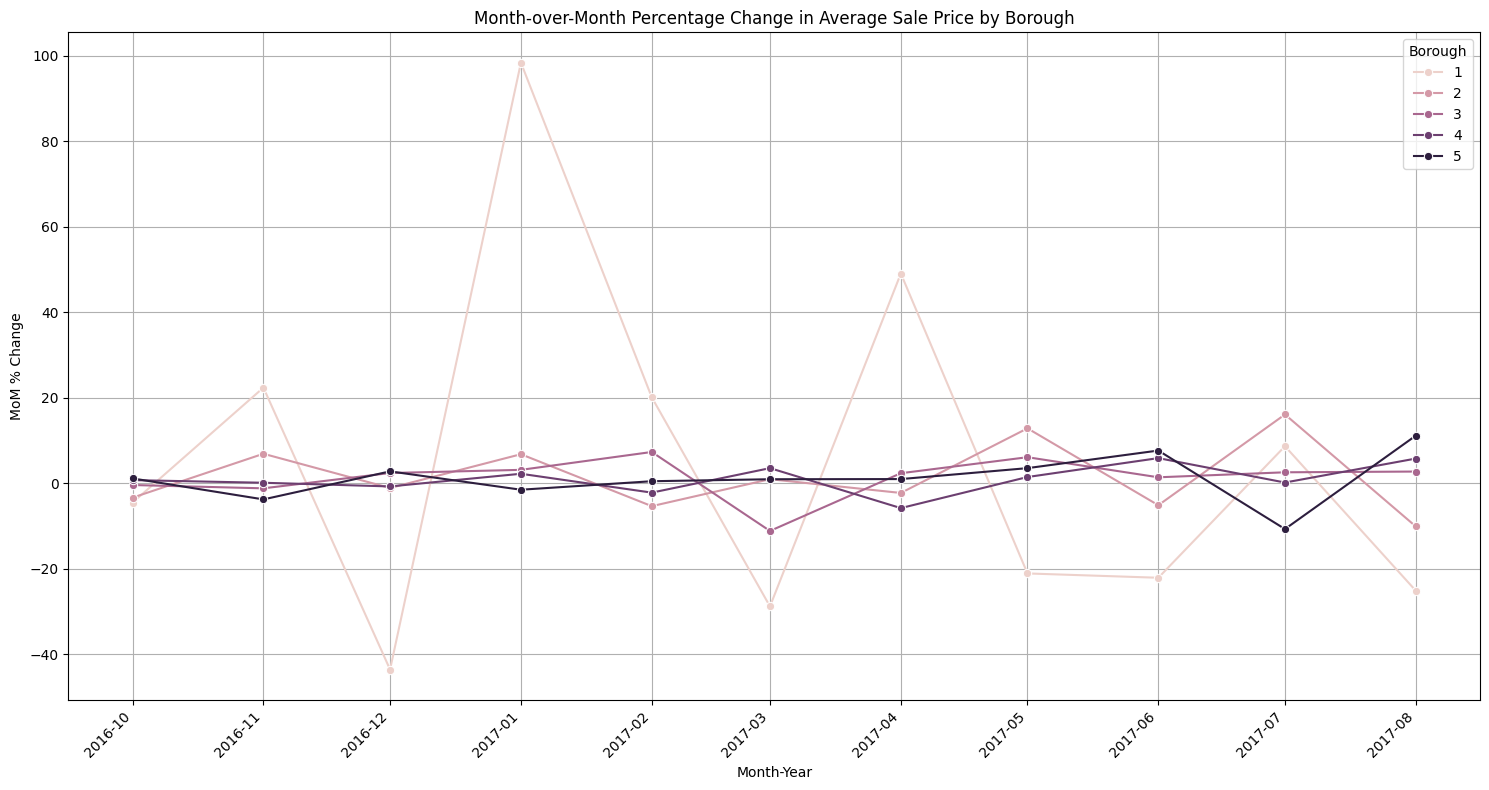

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Re-displaying the month-over-month calculation and plot from cell 0c6098aa
# This assumes df, avg_price_by_borough_month, and related columns are already defined

# Ensure 'SALE DATE' is in datetime format and 'SALE_MONTH_YEAR' is calculated
# (These steps were performed in cell de4eac06 and 0c6098aa)
# df['SALE DATE'] = pd.to_datetime(df['SALE DATE'])
# df['SALE_MONTH_YEAR'] = df['SALE DATE'].dt.to_period('M')

# Re-calculate avg_price_by_borough_month if necessary, or just use the existing one
# avg_price_by_borough_month = df.groupby(['BOROUGH', 'SALE_MONTH_YEAR'])['SALE PRICE'].mean().reset_index()
# avg_price_by_borough_month = avg_price_by_borough_month.sort_values(by=['BOROUGH', 'SALE_MONTH_YEAR'])
# avg_price_by_borough_month['PREV_MONTH_SALE_PRICE'] = avg_price_by_borough_month.groupby('BOROUGH')['SALE PRICE'].shift(1)
# avg_price_by_borough_month['MOM_PERCENT_CHANGE'] = ((avg_price_by_borough_month['SALE PRICE'] - avg_price_by_borough_month['PREV_MONTH_SALE_PRICE']) / avg_price_by_borough_month['PREV_MONTH_SALE_PRICE']) * 100

# Convert SALE_MONTH_YEAR to datetime for plotting (if not already done)
if 'SALE_MONTH_YEAR_DT' not in avg_price_by_borough_month.columns:
    avg_price_by_borough_month['SALE_MONTH_YEAR_DT'] = avg_price_by_borough_month['SALE_MONTH_YEAR'].dt.to_timestamp()

print("Month-over-Month Percentage Change in Average Sale Price by Borough:")
print(avg_price_by_borough_month.dropna(subset=['MOM_PERCENT_CHANGE']).set_index(['BOROUGH', 'SALE_MONTH_YEAR']))

# Visualize the Month-over-Month percentage change for each borough
plt.figure(figsize=(15, 8))
sns.lineplot(data=avg_price_by_borough_month, x='SALE_MONTH_YEAR_DT', y='MOM_PERCENT_CHANGE', hue='BOROUGH', marker='o')
plt.title('Month-over-Month Percentage Change in Average Sale Price by Borough')
plt.xlabel('Month-Year')
plt.ylabel('MoM % Change')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.legend(title='Borough')
plt.tight_layout()
plt.show()

## Quarter-over-Quarter (QoQ) Price Growth Analysis

Quarter-over-Quarter Percentage Change in Average Sale Price by Borough:
                        SALE PRICE  PREV_QUARTER_SALE_PRICE  \
BOROUGH SALE_QUARTER                                          
1       2016Q4        5.299801e+06             5.777059e+06   
        2017Q1        7.567501e+06             5.299801e+06   
        2017Q2        7.530961e+06             7.567501e+06   
        2017Q3        5.430137e+06             7.530961e+06   
2       2016Q4        4.558766e+05             4.527313e+05   
        2017Q1        4.763823e+05             4.558766e+05   
        2017Q2        4.905366e+05             4.763823e+05   
        2017Q3        5.455296e+05             4.905366e+05   
3       2016Q4        9.474883e+05             9.513474e+05   
        2017Q1        9.935273e+05             9.474883e+05   
        2017Q2        1.010034e+06             9.935273e+05   
        2017Q3        1.075972e+06             1.010034e+06   
4       2016Q4        6.621988e+05           

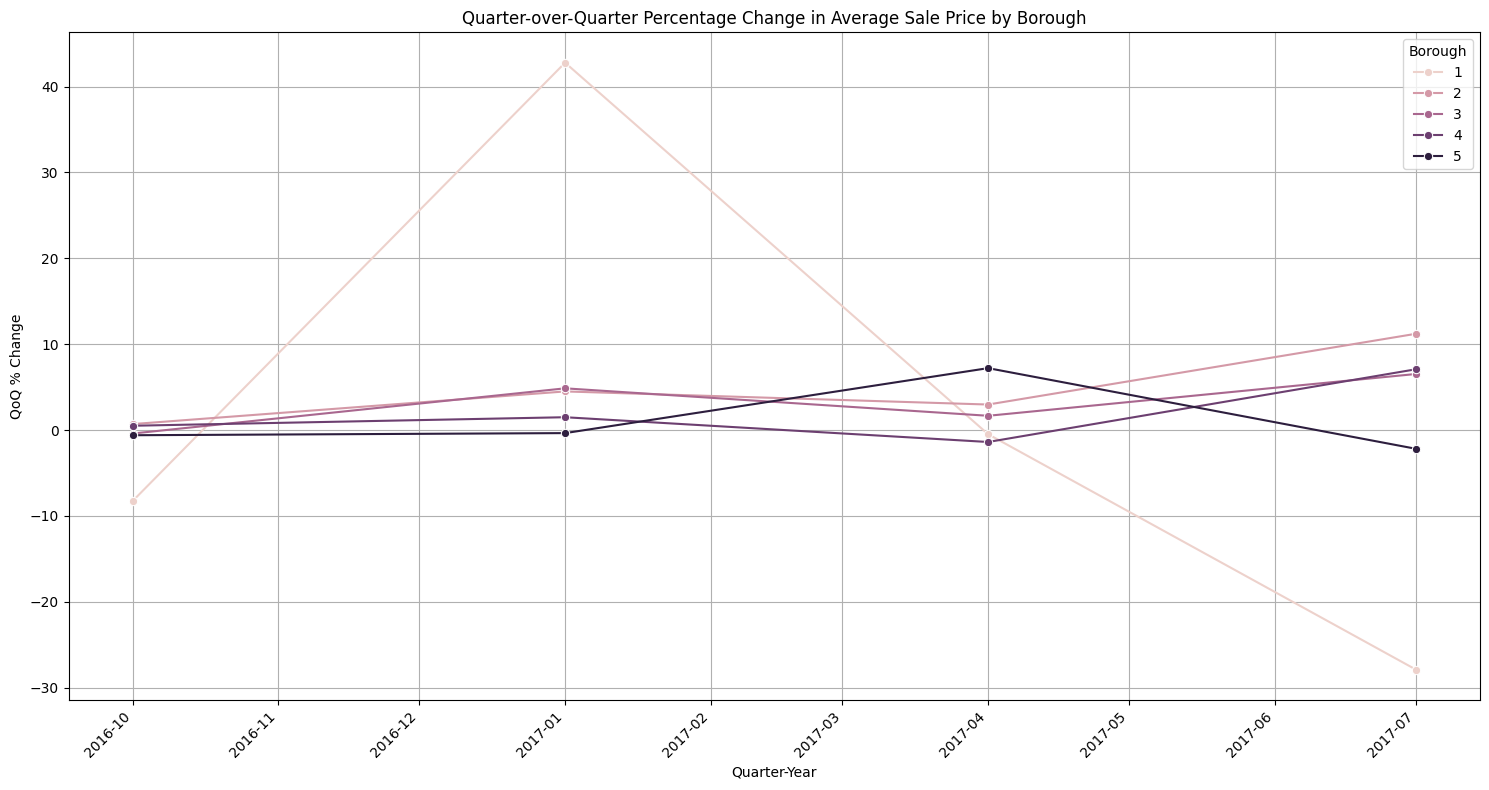

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'SALE DATE' is in datetime format
df['SALE DATE'] = pd.to_datetime(df['SALE DATE'])

# Extract year and quarter to create a quarterly period
df['SALE_QUARTER'] = df['SALE DATE'].dt.to_period('Q')

# Calculate average sale price by borough and quarter
avg_price_by_borough_quarter = df.groupby(['BOROUGH', 'SALE_QUARTER'])['SALE PRICE'].mean().reset_index()

# Sort by borough and quarter to ensure correct shifting
avg_price_by_borough_quarter = avg_price_by_borough_quarter.sort_values(by=['BOROUGH', 'SALE_QUARTER'])

# Calculate the previous quarter's average sale price within each borough group
avg_price_by_borough_quarter['PREV_QUARTER_SALE_PRICE'] = avg_price_by_borough_quarter.groupby('BOROUGH')['SALE PRICE'].shift(1)

# Calculate the Quarter-over-Quarter percentage change
avg_price_by_borough_quarter['QOQ_PERCENT_CHANGE'] = ((avg_price_by_borough_quarter['SALE PRICE'] - avg_price_by_borough_quarter['PREV_QUARTER_SALE_PRICE']) / avg_price_by_borough_quarter['PREV_QUARTER_SALE_PRICE']) * 100

print("Quarter-over-Quarter Percentage Change in Average Sale Price by Borough:")
print(avg_price_by_borough_quarter.dropna(subset=['QOQ_PERCENT_CHANGE']).set_index(['BOROUGH', 'SALE_QUARTER']))

# Convert SALE_QUARTER to datetime for plotting
avg_price_by_borough_quarter['SALE_QUARTER_DT'] = avg_price_by_borough_quarter['SALE_QUARTER'].dt.to_timestamp()

# Visualize the Quarter-over-Quarter percentage change for each borough
plt.figure(figsize=(15, 8))
sns.lineplot(data=avg_price_by_borough_quarter, x='SALE_QUARTER_DT', y='QOQ_PERCENT_CHANGE', hue='BOROUGH', marker='o')
plt.title('Quarter-over-Quarter Percentage Change in Average Sale Price by Borough')
plt.xlabel('Quarter-Year')
plt.ylabel('QoQ % Change')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.legend(title='Borough')
plt.tight_layout()
plt.show()


### Identifying Most Consistent Appreciation

To determine 'most consistent' appreciation, we look for boroughs with relatively stable, positive QoQ growth and fewer drastic fluctuations. Given the limited data range (2016 Q3 to 2017 Q3), a robust assessment of 'consistency' is challenging, but we can observe trends.

From the chart above and the calculated QoQ changes, we can look for:

*   **Positive Growth:** Boroughs that consistently show positive QoQ percentage changes.
*   **Smaller Fluctuations:** Boroughs where the QoQ changes are not extremely volatile.

Looking at the `QOQ_PERCENT_CHANGE` values and the plot, we can analyze the growth patterns:


In [45]:
# Calculate the standard deviation of QoQ changes to quantify consistency (lower std dev indicates more consistency)
consistency_metrics = avg_price_by_borough_quarter.groupby('BOROUGH')['QOQ_PERCENT_CHANGE'].agg(['mean', 'std']).dropna()

print("Mean and Standard Deviation of QoQ Percentage Change by Borough:")
print(consistency_metrics.apply(lambda x: pd.Series([f'{x[0]:.2f}%', f'{x[1]:.2f}%'], index=['mean', 'std']), axis=1))

# Identify borough with highest mean positive growth and lowest standard deviation (if applicable)
if not consistency_metrics.empty:
    # Filter for positive mean growth if desired
    positive_growth_metrics = consistency_metrics[consistency_metrics['mean'] > 0]

    if not positive_growth_metrics.empty:
        # Sort by mean (descending) and then by std (ascending) to find 'consistently high growth'
        most_consistent_growth = positive_growth_metrics.sort_values(by=['mean', 'std'], ascending=[False, True]).iloc[0]
        most_consistent_borough_id = most_consistent_growth.name
        most_consistent_borough_mean = most_consistent_growth['mean']
        most_consistent_borough_std = most_consistent_growth['std']

        # Map borough ID to name
        borough_to_county_name = {
            1: 'New York County (Manhattan)',
            2: 'Bronx County',
            3: 'Kings County (Brooklyn)',
            4: 'Queens County',
            5: 'Richmond County (Staten Island)'
        }
        most_consistent_borough_name = borough_to_county_name.get(most_consistent_borough_id, f'Borough {most_consistent_borough_id}')

        print(f"\nThe borough with the most consistently high positive QoQ price growth appears to be {most_consistent_borough_name}, with an average QoQ growth of {most_consistent_borough_mean:.2f}% and a standard deviation of {most_consistent_borough_std:.2f}% (indicating relatively stable growth).")
    else:
        print("No boroughs showed a positive average QoQ growth over the period.")
else:
    print("Not enough data to calculate consistency metrics.")

Mean and Standard Deviation of QoQ Percentage Change by Borough:
          mean     std
BOROUGH               
1        1.54%  29.82%
2        4.84%   4.52%
3        3.16%   3.12%
4        1.92%   3.64%
5        1.02%   4.21%

The borough with the most consistently high positive QoQ price growth appears to be Bronx County, with an average QoQ growth of 4.84% and a standard deviation of 4.52% (indicating relatively stable growth).


/tmp/ipykernel_6988/598669501.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(consistency_metrics.apply(lambda x: pd.Series([f'{x[0]:.2f}%', f'{x[1]:.2f}%'], index=['mean', 'std']), axis=1))


In [46]:
df.head()

,Unnamed: 0,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,...,PRICE_PER_SQFT,SALE_YEAR,SALE_MONTH_YEAR,YEAR_BUILT_CATEGORY,SALE_MONTH_NUM,BUILDING_ERA,BOROUGH_AVG_SALE_PRICE,LUXURY_THRESHOLD,IS_LUXURY,SALE_QUARTER
0,210,1,CHELSEA,01 ONE FAMILY DWELLINGS,1,771,52,,A9,224 WEST 22ND STREET,...,1926.070039,2016,2016-12,1900-1939,12,pre-1950,6.574102e+06,1.314820e+07,False,2016Q4
1,216,1,CHELSEA,02 TWO FAMILY DWELLINGS,1,769,49,,S2,218 WEST 20TH STREET,...,1556.850141,2017,2017-04,1900-1939,4,pre-1950,6.574102e+06,1.314820e+07,False,2017Q2
2,218,1,CHELSEA,03 THREE FAMILY DWELLINGS,1,719,67,,C0,444 WEST 22ND STREET,...,2228.187919,2017,2017-02,1900-1939,2,pre-1950,6.574102e+06,1.314820e+07,False,2017Q1
3,1795,1,EAST VILLAGE,02 TWO FAMILY DWELLINGS,1,436,1,,S2,138 1 AVENUE,...,892.857143,2017,2017-08,1900-1939,8,pre-1950,6.574102e+06,1.314820e+07,False,2017Q3
4,1797,1,EAST VILLAGE,02 TWO FAMILY DWELLINGS,1,458,47,,S2,4 EAST 2ND STREET,...,1148.648649,2017,2017-01,Pre-1900,1,pre-1950,6.574102e+06,1.314820e+07,False,2017Q1


In [47]:
import pandas as pd

# Convert date
df['SALE DATE'] = pd.to_datetime(df['SALE DATE'])

# Filter Bronx and explicitly create a copy to avoid SettingWithCopyWarning
bronx_df = df[df['COUNTY_NAME'] == 'Bronx County'].copy() # Changed to 'Bronx County' as seen in kernel state

# Create Year + Quarter
bronx_df['year'] = bronx_df['SALE DATE'].dt.year
bronx_df['quarter'] = bronx_df['SALE DATE'].dt.quarter

# Aggregate average price per quarter
quarterly = bronx_df.groupby(['year', 'quarter'])['SALE PRICE'].mean().reset_index()

# Calculate QoQ growth
quarterly['qoq_growth_pct'] = quarterly['SALE PRICE'].pct_change() * 100

# Calculate metrics
avg_growth = quarterly['qoq_growth_pct'].mean()
volatility = quarterly['qoq_growth_pct'].std()

print("Average QoQ Growth:", avg_growth)
print(f"Volatility (Std Dev): {volatility}") # Corrected print statement

Average QoQ Growth: 4.843702023919971
Volatility (Std Dev): 4.523235476449321


In [48]:
# Ensure 'SALE DATE' is in datetime format and 'SALE_QUARTER' is extracted
df['SALE DATE'] = pd.to_datetime(df['SALE DATE'])
df['SALE_QUARTER'] = df['SALE DATE'].dt.to_period('Q')

# Calculate average sale price by neighborhood and quarter
avg_price_by_neighborhood_quarter = df.groupby(['NEIGHBORHOOD', 'SALE_QUARTER'])['SALE PRICE'].mean().reset_index()

# Sort by neighborhood and quarter to ensure correct shifting
avg_price_by_neighborhood_quarter = avg_price_by_neighborhood_quarter.sort_values(by=['NEIGHBORHOOD', 'SALE_QUARTER'])

# Calculate the previous quarter's average sale price within each neighborhood group
avg_price_by_neighborhood_quarter['PREV_QUARTER_SALE_PRICE'] = avg_price_by_neighborhood_quarter.groupby('NEIGHBORHOOD')['SALE PRICE'].shift(1)

# Calculate the Quarter-over-Quarter percentage change
avg_price_by_neighborhood_quarter['QOQ_PERCENT_CHANGE'] = ((avg_price_by_neighborhood_quarter['SALE PRICE'] - avg_price_by_neighborhood_quarter['PREV_QUARTER_SALE_PRICE']) / avg_price_by_neighborhood_quarter['PREV_QUARTER_SALE_PRICE']) * 100

# Calculate the mean and standard deviation of QoQ changes for each neighborhood
neighborhood_consistency_metrics = avg_price_by_neighborhood_quarter.groupby('NEIGHBORHOOD')['QOQ_PERCENT_CHANGE'].agg(['mean', 'std']).dropna()

print("Mean and Standard Deviation of QoQ Percentage Change by Neighborhood:")
# Display top and bottom of the metrics for inspection
print(neighborhood_consistency_metrics.apply(lambda x: pd.Series([f'{x[0]:.2f}%', f'{x[1]:.2f}%'], index=['mean', 'std']), axis=1).head())
print("...")
print(neighborhood_consistency_metrics.apply(lambda x: pd.Series([f'{x[0]:.2f}%', f'{x[1]:.2f}%'], index=['mean', 'std']), axis=1).tail())

# Identify neighborhood with most consistent growth and low volatility
if not neighborhood_consistency_metrics.empty:
    # Filter for positive mean growth
    positive_growth_neighborhoods = neighborhood_consistency_metrics[neighborhood_consistency_metrics['mean'] > 0]

    if not positive_growth_neighborhoods.empty:
        # Sort by standard deviation (ascending) first to prioritize low volatility,
        # then by mean (descending) to get higher growth among low volatility options.
        most_consistent_growth_neighborhood = positive_growth_neighborhoods.sort_values(by=['std', 'mean'], ascending=[True, False]).iloc[0]
        most_consistent_neighborhood_name = most_consistent_growth_neighborhood.name
        most_consistent_neighborhood_mean = most_consistent_growth_neighborhood['mean']
        most_consistent_neighborhood_std = most_consistent_growth_neighborhood['std']

        print(f"\nThe neighborhood with the most consistently high positive QoQ price growth and low volatility is {most_consistent_neighborhood_name}, with an average QoQ growth of {most_consistent_neighborhood_mean:.2f}% and a standard deviation of {most_consistent_neighborhood_std:.2f}%.")
    else:
        print("No neighborhoods showed a positive average QoQ growth over the period with enough data for consistency analysis.")
else:
    print("Not enough data to calculate consistency metrics for neighborhoods.")

Mean and Standard Deviation of QoQ Percentage Change by Neighborhood:
                        mean     std
NEIGHBORHOOD                        
ANNADALE              -0.02%  11.18%
ARDEN HEIGHTS          2.66%   5.18%
ARROCHAR               7.81%  44.36%
ARROCHAR-SHORE ACRES   3.89%  48.08%
ARVERNE                8.63%  16.29%
...
                   mean     std
NEIGHBORHOOD                   
WOODHAVEN         0.67%   9.42%
WOODLAWN          3.96%  10.78%
WOODROW          -3.64%  12.75%
WOODSIDE         -1.16%  24.69%
WYCKOFF HEIGHTS   3.42%  40.31%

The neighborhood with the most consistently high positive QoQ price growth and low volatility is MILL BASIN, with an average QoQ growth of 0.73% and a standard deviation of 1.69%.


/tmp/ipykernel_6988/2252474754.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(neighborhood_consistency_metrics.apply(lambda x: pd.Series([f'{x[0]:.2f}%', f'{x[1]:.2f}%'], index=['mean', 'std']), axis=1).head())
/tmp/ipykernel_6988/2252474754.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(neighborhood_consistency_metrics.apply(lambda x: pd.Series([f'{x[0]:.2f}%', f'{x[1]:.2f}%'], index=['mean', 'std']), axis=1).tail())
